In [ ]:
!wget -q https://raw.githubusercontent.com/googlecolab/colabtools/master/colabtools/notebooks/high_memory.ipynb



In [ ]:
# Import necessary libraries
from google.colab import drive
import os

# Check if the mountpoint already exists and is not empty
mountpoint = '/content/drive'
if os.path.exists(mountpoint) and os.listdir(mountpoint):
    # If it's not empty, remove existing files or choose a different mountpoint
    !rm -rf /content/drive  # Use with caution! This deletes all content in /content/drive
    # or
    # mountpoint = '/content/drive_new'  # Define a new mountpoint

# Mount Google Drive to the chosen mountpoint
drive.mount(mountpoint)

Mounted at /content/drive


In [ ]:
import os

# Replace with the actual path to your dataset
dataset_path = '/content/drive/My Drive/Dataset/Mammogram_dataset'
os.chdir(dataset_path)


In [ ]:
# List the contents of the dataset directory
!ls -l

total 482773
-rw------- 1 root root 140283412 Oct 21  2024 best_model.keras
-rw------- 1 root root 343282154 May 21 08:33 best_vit_attn.pth
-rw------- 1 root root   2854100 Apr  6 02:50 breast-level_annotations.csv
drwx------ 2 root root      4096 Apr  1 11:04 datasets
-rw------- 1 root root     21404 Oct  3  2024 Final_Mammogram_Project_Report.docx
-rw------- 1 root root   3495811 Oct 30  2024 finding_annotations.csv
-rw------- 1 root root       177 Oct  6  2024 finding_annotations.gsheet
drwx------ 2 root root      4096 Sep  1  2024 images
-rw------- 1 root root   4360150 Apr  6 02:50 metadata.csv
drwx------ 2 root root      4096 Mar 29 09:04 pytorch-CycleGAN-and-pix2pix
-rw------- 1 root root     48458 Jun 15 06:59 random_preprocessed_collage.png


In [ ]:
import pandas as pd

# Load the CSV files
breast_annotations = pd.read_csv('breast-level_annotations.csv')
finding_annotations = pd.read_csv('finding_annotations.csv')
metadata = pd.read_csv('metadata.csv')

# Display the first few rows of each DataFrame
print("Breast-Level Annotations:")
print(breast_annotations.head())

print("\nFinding Annotations:")
print(finding_annotations.head())

print("\nMetadata:")
print(metadata.head())

Breast-Level Annotations:
                           study_id                         series_id  \
0  b8d273e8601f348d3664778dae0e7e0b  b36517b9cbbcfd286a7ae04f643af97a   
1  b8d273e8601f348d3664778dae0e7e0b  b36517b9cbbcfd286a7ae04f643af97a   
2  b8d273e8601f348d3664778dae0e7e0b  b36517b9cbbcfd286a7ae04f643af97a   
3  b8d273e8601f348d3664778dae0e7e0b  b36517b9cbbcfd286a7ae04f643af97a   
4  8269f5971eaca3e5d3772d1796e6bd7a  d931832a0815df082c085b6e09d20aac   

                           image_id laterality view_position  height  width  \
0  d8125545210c08e1b1793a5af6458ee2          L            CC    3518   2800   
1  290c658f4e75a3f83ec78a847414297c          L           MLO    3518   2800   
2  cd0fc7bc53ac632a11643ac4cc91002a          R            CC    3518   2800   
3  71638b1e853799f227492bfb08a01491          R           MLO    3518   2800   
4  dd9ce3288c0773e006a294188aadba8e          L            CC    3518   2800   

  breast_birads breast_density     split  
0     BI-RADS 2  

In [ ]:
# BI-RADS Categories Distribution
birads_distribution = breast_annotations['breast_birads'].value_counts()
print("BI-RADS Distribution:\n", birads_distribution)

# Breast Density Levels Distribution
density_distribution = breast_annotations['breast_density'].value_counts()
print("\nBreast Density Distribution:\n", density_distribution)

# Finding Categories Distribution
finding_categories_distribution = finding_annotations['finding_categories'].explode().value_counts()
print("\nFinding Categories Distribution:\n", finding_categories_distribution)

# Image Dimensions Distribution
image_dimensions = breast_annotations[['width', 'height']].drop_duplicates()
print("\nUnique Image Dimensions:\n", image_dimensions)


BI-RADS Distribution:
 breast_birads
BI-RADS 1    13406
BI-RADS 2     4676
BI-RADS 3      930
BI-RADS 4      762
BI-RADS 5      226
Name: count, dtype: int64

Breast Density Distribution:
 breast_density
DENSITY C    15292
DENSITY D     2700
DENSITY B     1908
DENSITY A      100
Name: count, dtype: int64

Finding Categories Distribution:
 finding_categories
['No Finding']                                                                                      18232
['Mass']                                                                                             1123
['Suspicious Calcification']                                                                          402
['Focal Asymmetry']                                                                                   232
['Architectural Distortion']                                                                           95
['Asymmetry']                                                                                          90
['Su

In [ ]:
!pip install pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 80.8 MB/s eta 0:00:00


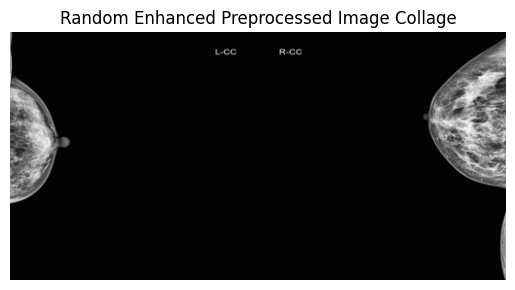

Collage saved as random_enhanced_preprocessed_collage.png


In [ ]:
!pip install opencv-python

import os
import random
from PIL import Image
import matplotlib.pyplot as plt
import cv2
import numpy as np

# Define the directory containing preprocessed images
preprocessed_dir = "/content/drive/MyDrive/Processed_Mammogram_Dataset_1"

# Function to enhance image quality
def enhance_image(image_path):
    try:
        # Read image using OpenCV
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            print(f"Warning: Could not load image {image_path}")
            return None

        # Apply CLAHE for contrast enhancement
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        enhanced_img = clahe.apply(img)

        # You can add other enhancement steps here, e.g., denoising
        # enhanced_img = cv2.fastNlMeansDenoising(enhanced_img, None, 10, 7, 21)

        # Convert back to PIL Image
        enhanced_img_pil = Image.fromarray(enhanced_img)
        return enhanced_img_pil.convert('RGB')

    except Exception as e:
        print(f"Error enhancing image {image_path}: {e}")
        return None


# Collect all image paths
image_paths = []
for root, _, files in os.walk(preprocessed_dir):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            image_paths.append(os.path.join(root, file))

# Check if there are enough images
if len(image_paths) < 2:
    print("Not enough preprocessed images to create a collage.")
else:
    # Select 2 random images
    selected_images = random.sample(image_paths, 2)

    # Load and prepare images for collage with enhancement
    images_for_collage = []
    try:
        for img_path in selected_images:
            enhanced_img = enhance_image(img_path)
            if enhanced_img:
                # Resize images to a common size (optional, but helps with collage appearance)
                enhanced_img = enhanced_img.resize((256, 256))
                images_for_collage.append(enhanced_img)

        if len(images_for_collage) < 2:
            print("Could not enhance enough images to create a collage.")
        else:
            # Create a blank image for the collage
            collage_width = images_for_collage[0].width * 2
            collage_height = images_for_collage[0].height
            collage = Image.new('RGB', (collage_width, collage_height))

            # Paste images into the collage
            collage.paste(images_for_collage[0], (0, 0))
            collage.paste(images_for_collage[1], (images_for_collage[0].width, 0))

            # Display the collage
            plt.imshow(collage)
            plt.axis('off') # Hide axes
            plt.title("Random Enhanced Preprocessed Image Collage")
            plt.show()

            # Save the collage image
            collage_filename = "random_enhanced_preprocessed_collage.png"
            collage.save(collage_filename)
            print(f"Collage saved as {collage_filename}")

    except Exception as e:
        print(f"An error occurred: {e}")

In [ ]:
import pydicom
import matplotlib.pyplot as plt

# Define the base path to the dataset on Google Drive
base_path = '/content/drive/My Drive/Dataset/Mammogram_dataset'

# Specify the study ID and choose a file name directly from the list you provided
study_id = 'b8d273e8601f348d3664778dae0e7e0b'
dicom_file = '290c658f4e75a3f83ec78a847414297c.dicom'

# Construct the path to the DICOM image
image_path = f'{base_path}/images/{study_id}/{dicom_file}'

# Function to load and display a DICOM image
def display_dicom_image(image_path):
    dicom = pydicom.dcmread(image_path)
    plt.imshow(dicom.pixel_array, cmap=plt.cm.gray)
    plt.axis('off')
    plt.show()

# Display the DICOM image using the verified path
display_dicom_image(image_path)


In [ ]:
import os
import pydicom
import matplotlib.pyplot as plt

# Define the base path to the dataset on Google Drive
base_path = '/content/drive/My Drive/Dataset/Mammogram_dataset/images'

# Specify the study ID you want to visualize
specified_study_id = 'fa4dcd0f3ba24e86fc8dc25091f7ebd5'  # Replace 'your_study_id_here' with the actual study_id

# Construct the path to the study directory
study_path = os.path.join(base_path, specified_study_id)

# Function to display a DICOM image
def display_dicom_image(image_path):
    dicom = pydicom.dcmread(image_path)
    plt.imshow(dicom.pixel_array, cmap=plt.cm.gray)
    plt.axis('off')  # Hide the axes
    plt.show()

# Check if the specified directory exists
if os.path.exists(study_path):
    # List all DICOM files in the specified study directory
    dicom_files = [os.path.join(study_path, f) for f in os.listdir(study_path) if f.endswith('.dicom')]
    if dicom_files:
        print(f"Displaying {len(dicom_files)} DICOM images from study ID {specified_study_id}:")
        for file_path in dicom_files:
            display_dicom_image(file_path)
    else:
        print("No DICOM files found in the specified study directory.")
else:
    print(f"The specified study directory {study_path} does not exist.")


ModuleNotFoundError: No module named 'pydicom'

In [ ]:
import os
import pandas as pd
import pydicom
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random

# Define the base path to the dataset on Google Drive
base_path = '/content/drive/My Drive/Dataset/Mammogram_dataset'

# Load annotations
annotations_df = pd.read_csv(f'{base_path}/finding_annotations.csv')

# Filter annotations for rows that have bounding boxes (i.e., xmin, ymin, xmax, ymax are not null)
annotations_with_boxes = annotations_df.dropna(subset=['xmin', 'ymin', 'xmax', 'ymax'])

# List all unique study directories that have bounding boxes
study_directories_with_boxes = annotations_with_boxes['study_id'].unique()

# Randomly select five study directories that have bounding boxes
selected_studies = random.sample(list(study_directories_with_boxes), 5) if len(study_directories_with_boxes) >= 5 else study_directories_with_boxes

# Function to display DICOM images for a given study with bounding boxes
def display_images_with_boxes_for_study(study_id):
    # Filter annotations specific to this study
    study_annotations = annotations_with_boxes[annotations_with_boxes['study_id'] == study_id]

    # List all DICOM files associated with this study
    dicom_files = os.listdir(f'{base_path}/images/{study_id}')

    fig, axs = plt.subplots(1, len(dicom_files), figsize=(30, 10))  # Adjust figure size
    if len(dicom_files) == 1:  # In case of one image, we avoid having axs as an array
        axs = [axs]

    for idx, image_file in enumerate(dicom_files):
        image_path = f'{base_path}/images/{study_id}/{image_file}'
        dicom = pydicom.dcmread(image_path)
        image_id = image_file.split('.')[0]

        axs[idx].imshow(dicom.pixel_array, cmap='gray')
        axs[idx].set_title(f'Image ID: {image_id}')

        # Filter and display bounding boxes for this specific image
        specific_annotations = study_annotations[study_annotations['image_id'] == image_id]
        for index, row in specific_annotations.iterrows():
            rect = patches.Rectangle((row['xmin'], row['ymin']), row['xmax'] - row['xmin'], row['ymax'] - row['ymin'],
                                     linewidth=1, edgecolor='r', facecolor='none')
            axs[idx].add_patch(rect)

        axs[idx].axis('off')

    plt.tight_layout()
    plt.show()

# Display 5 randomly selected study IDs, one per row with images and bounding boxes
print("Selected Study IDs and Their Images with Bounding Boxes:")
for study_id in selected_studies:
    print(f"\nDisplaying images for Study ID: {study_id}")
    display_images_with_boxes_for_study(study_id)


In [ ]:
import os
import pandas as pd
import pydicom
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np

# Define paths
base_path = '/content/drive/MyDrive/Dataset/Mammogram_dataset'  # Adjust this to your dataset's location
images_dir = os.path.join(base_path, 'images')  # Directory containing all study folders
annotations_path = os.path.join(base_path, 'finding_annotations.csv')  # CSV file with annotations
breast_annotations_path = os.path.join(base_path, 'breast-level_annotations.csv')  # Breast-level annotations CSV

# Load annotations
finding_annotations_df = pd.read_csv(annotations_path)
breast_annotations_df = pd.read_csv(breast_annotations_path)

# Filter only rows with valid bounding boxes (no NaN values in xmin, ymin, xmax, ymax)
finding_annotations_df = finding_annotations_df.dropna(subset=['xmin', 'ymin', 'xmax', 'ymax'])

# Function to load a DICOM image, normalize and convert to a PIL image
def load_dicom_image(image_path):
    dicom = pydicom.dcmread(image_path)
    pixel_array = dicom.pixel_array
    normalized_image = (pixel_array - np.min(pixel_array)) / (np.max(pixel_array) - np.min(pixel_array)) * 255.0
    pil_image = Image.fromarray(normalized_image.astype(np.uint8))
    return pil_image

# Function to extract and display the ROI based on the bounding box
def extract_roi(image, bbox):
    xmin, ymin, xmax, ymax = bbox
    roi = image.crop((xmin, ymin, xmax, ymax))
    return roi

# Display sample ROIs from the dataset
sample_size = 5
processed_samples = 0

plt.figure(figsize=(15, 10))

# Loop through a sample of study folders to extract and display ROIs
for study_id in os.listdir(images_dir):
    study_path = os.path.join(images_dir, study_id)

    if not os.path.isdir(study_path):
        continue

    for image_file in os.listdir(study_path):
        if image_file.endswith('.dicom'):
            # Extract image_id from the file name (without the .dicom extension)
            image_id = image_file.split('.')[0]
            image_path = os.path.join(study_path, image_file)

            # Find the bounding box annotations for the current image
            image_annotations = finding_annotations_df[(finding_annotations_df['study_id'] == study_id) & (finding_annotations_df['image_id'] == image_id)]

            # If we have annotations, proceed to extract the ROI
            if not image_annotations.empty:
                for _, row in image_annotations.iterrows():
                    bbox = (row['xmin'], row['ymin'], row['xmax'], row['ymax'])

                    # Load the DICOM image
                    image = load_dicom_image(image_path)

                    # Extract the ROI
                    roi = extract_roi(image, bbox)

                    # Display the full image with bounding box and the extracted ROI
                    fig, ax = plt.subplots(1, 2, figsize=(10, 5))

                    # Display full image with bounding box
                    ax[0].imshow(image, cmap='gray')
                    rect = patches.Rectangle((row['xmin'], row['ymin']), row['xmax'] - row['xmin'], row['ymax'] - row['ymin'],
                                             linewidth=2, edgecolor='r', facecolor='none')
                    ax[0].add_patch(rect)
                    ax[0].set_title(f"Full Image with ROI (Study ID: {study_id})")
                    ax[0].axis('off')

                    # Display extracted ROI
                    ax[1].imshow(roi, cmap='gray')
                    ax[1].set_title(f"Extracted ROI (Image ID: {image_id})")
                    ax[1].axis('off')

                    plt.tight_layout()
                    plt.show()

                    processed_samples += 1

                    # Stop after processing a small sample
                    if processed_samples >= sample_size:
                        break

    if processed_samples >= sample_size:
        break


In [ ]:
!pip install PyWavelets

In [ ]:
import os
import numpy as np
import cv2
import pydicom
import pywt
from skimage.filters import threshold_otsu
from concurrent.futures import ProcessPoolExecutor
from glob import glob

# Define paths
input_dir = "/content/drive/MyDrive/Dataset/Mammogram_dataset/images"
output_dir = "/content/drive/MyDrive/Processed_Mammogram_Dataset_1"  # Updated output directory name
os.makedirs(output_dir, exist_ok=True)

# Function for Wavelet Denoising
def wavelet_denoising(image):
    coeffs2 = pywt.dwt2(image, 'haar')
    LL, (LH, HL, HH) = coeffs2
    coeffs2 = LL, (np.zeros_like(LH), np.zeros_like(HL), np.zeros_like(HH))
    return pywt.idwt2(coeffs2, 'haar')

# Function for CLAHE + Unsharp Masking with dtype check
def enhance_contrast(image):
    # Ensure the image is in 8-bit format
    if image.dtype != np.uint8:
        image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    image_clahe = clahe.apply(image)
    gaussian_blur = cv2.GaussianBlur(image_clahe, (0, 0), 3)
    return cv2.addWeighted(image_clahe, 1.5, gaussian_blur, -0.5, 0)

# Function for Background Removal using Otsu’s Thresholding
def remove_background(image):
    thresh_val = threshold_otsu(image)
    binary_mask = image > thresh_val
    image[binary_mask == 0] = 0
    return image

# Function to Add Adaptive Reflection Padding (only pads if image is smaller than target)
def add_padding(image, target_size=(512, 512)):
    h, w = image.shape
    pad_top = max((target_size[0] - h) // 2, 0)
    pad_bottom = max(target_size[0] - h - pad_top, 0)
    pad_left = max((target_size[1] - w) // 2, 0)
    pad_right = max(target_size[1] - w - pad_left, 0)
    return cv2.copyMakeBorder(image, pad_top, pad_bottom, pad_left, pad_right, cv2.BORDER_REFLECT)

# Function to Normalize and Resize Image
def preprocess_image(image, target_size=(512, 512)):
    image = add_padding(image, target_size)  # Apply padding when needed
    image = cv2.resize(image, target_size, interpolation=cv2.INTER_AREA)
    image = image.astype(np.float32) / 255.0  # Normalize
    return image

# Function to process each DICOM file
def process_dicom(dicom_path, output_dir):
    try:
        dicom_data = pydicom.dcmread(dicom_path)
        image = dicom_data.pixel_array

        # Convert to 8-bit grayscale
        image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

        # Apply preprocessing steps
        image = wavelet_denoising(image)
        image = enhance_contrast(image)
        image = remove_background(image)
        image = preprocess_image(image)

        # Create subdirectory structure in output folder based on study ID (folder name)
        study_id = os.path.basename(os.path.dirname(dicom_path))
        study_output_dir = os.path.join(output_dir, study_id)
        os.makedirs(study_output_dir, exist_ok=True)

        # Save processed image; replace '.dicom' extension with '.png'
        output_filename = os.path.join(study_output_dir, os.path.basename(dicom_path).replace('.dicom', '.png'))
        cv2.imwrite(output_filename, (image * 255).astype(np.uint8))
    except Exception as e:
        print(f"Error processing {dicom_path}: {e}")

# Batch processing function
def batch_process_dicom_files(input_dir, output_dir, batch_size=20):
    # Glob for all .dicom files in subdirectories under "images"
    dicom_files = glob(os.path.join(input_dir, "*", "*.dicom"), recursive=True)
    total_batches = len(dicom_files) // batch_size + (1 if len(dicom_files) % batch_size != 0 else 0)

    for i in range(0, len(dicom_files), batch_size):
        batch_files = dicom_files[i:i+batch_size]
        with ProcessPoolExecutor(max_workers=4) as executor:
            for dicom_path in batch_files:
                executor.submit(process_dicom, dicom_path, output_dir)
        print(f"Processed batch {i // batch_size + 1} of {total_batches}")

# Run batch processing
batch_process_dicom_files(input_dir, output_dir, batch_size=20)


In [ ]:
import os
import numpy as np
import cv2
import pydicom
import pywt
import pandas as pd
from skimage.filters import threshold_otsu
from skimage import exposure
from concurrent.futures import ProcessPoolExecutor
from glob import glob

# Define paths
input_dir = "/content/drive/MyDrive/Dataset/Mammogram_dataset/images"
annotation_file = "/content/drive/MyDrive/Dataset/Mammogram_dataset/finding_annotations.csv"
processed_img_dir = "/content/drive/MyDrive/Processed_Mammogram_Dataset_1"  # Updated output directory name
roi_output_dir = "/content/drive/MyDrive/Extracted_ROI_Mammogram_Dataset"
os.makedirs(roi_output_dir, exist_ok=True)

# Load annotations
annotations_df = pd.read_csv(annotation_file)
annotations_df.dropna(subset=["xmin", "ymin", "xmax", "ymax"], inplace=True)

# Helper functions remain the same

def wavelet_denoising(image):
    if image.size == 0:
        return image
    coeffs2 = pywt.dwt2(image, 'haar')
    LL, (LH, HL, HH) = coeffs2
    coeffs2 = LL, (np.zeros_like(LH), np.zeros_like(HL), np.zeros_like(HH))
    return pywt.idwt2(coeffs2, 'haar')

def enhance_contrast(image):
    if image.dtype != np.uint8:
        image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    image_clahe = clahe.apply(image)
    gaussian_blur = cv2.GaussianBlur(image_clahe, (0, 0), 3)
    return cv2.addWeighted(image_clahe, 1.5, gaussian_blur, -0.5, 0)

def remove_background(image):
    if image.size == 0:
        return image
    thresh_val = threshold_otsu(image)
    binary_mask = image > thresh_val
    image[binary_mask == 0] = 0
    return image

def add_padding(image, target_size=(512, 512)):
    h, w = image.shape
    top = (target_size[0] - h) // 2
    bottom = target_size[0] - h - top
    left = (target_size[1] - w) // 2
    right = target_size[1] - w - left
    return cv2.copyMakeBorder(image, top, bottom, left, right, cv2.BORDER_REFLECT)

def preprocess_image(image, target_size=(512, 512)):
    if image.size == 0:
        return None
    image = wavelet_denoising(image)
    image = enhance_contrast(image)
    image = remove_background(image)
    image = add_padding(image, target_size)
    image = cv2.resize(image, target_size, interpolation=cv2.INTER_AREA)
    image = image.astype(np.float32) / 255.0
    return image

# Function to extract ROI with padding and save it
def extract_and_save_roi(row):
    study_id = row['study_id']
    image_id = row['image_id']
    xmin, ymin, xmax, ymax = map(int, [row['xmin'], row['ymin'], row['xmax'], row['ymax']])

    image_path = os.path.join(processed_img_dir, study_id, f"{image_id}.png")
    if not os.path.exists(image_path):
        return

    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        return

    h, w = image.shape
    pad = int(0.1 * max(xmax - xmin, ymax - ymin))  # 10% padding
    xmin_p = max(0, xmin - pad)
    ymin_p = max(0, ymin - pad)
    xmax_p = min(w, xmax + pad)
    ymax_p = min(h, ymax + pad)

    roi = image[ymin_p:ymax_p, xmin_p:xmax_p]
    if roi.size == 0 or roi.shape[0] < 10 or roi.shape[1] < 10:
        return  # Skip too-small or empty ROIs

    roi = preprocess_image(roi)
    if roi is None:
        return

    roi_dir = os.path.join(roi_output_dir, study_id)
    os.makedirs(roi_dir, exist_ok=True)
    roi_path = os.path.join(roi_dir, f"{image_id}_roi.png")
    cv2.imwrite(roi_path, (roi * 255).astype(np.uint8))

# Apply to all annotations
annotations_df.apply(extract_and_save_roi, axis=1)
print("✅ ROI Extraction with preprocessing, padding, and multi-view ready images saved.")


In [ ]:
import os
import numpy as np
import cv2
import pydicom
import pywt
import pandas as pd
from skimage.filters import threshold_otsu
from skimage import exposure
from concurrent.futures import ProcessPoolExecutor
from glob import glob

# Define paths
input_dir = "/content/drive/MyDrive/Dataset/Mammogram_dataset/images"
annotation_file = "/content/drive/MyDrive/Dataset/Mammogram_dataset/finding_annotations.csv"
processed_img_dir = "/content/drive/MyDrive/Processed_Mammogram_Dataset_1"  # Updated output directory name
roi_output_dir = "/content/drive/MyDrive/Extracted_ROI_Mammogram_Dataset"
os.makedirs(roi_output_dir, exist_ok=True)

# Load annotations
annotations_df = pd.read_csv(annotation_file)
annotations_df.dropna(subset=["xmin", "ymin", "xmax", "ymax"], inplace=True)

# Helper functions remain the same

def wavelet_denoising(image):
    if image.size == 0:
        return image
    coeffs2 = pywt.dwt2(image, 'haar')
    LL, (LH, HL, HH) = coeffs2
    coeffs2 = LL, (np.zeros_like(LH), np.zeros_like(HL), np.zeros_like(HH))
    return pywt.idwt2(coeffs2, 'haar')

def enhance_contrast(image):
    if image.dtype != np.uint8:
        image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    image_clahe = clahe.apply(image)
    gaussian_blur = cv2.GaussianBlur(image_clahe, (0, 0), 3)
    return cv2.addWeighted(image_clahe, 1.5, gaussian_blur, -0.5, 0)

def remove_background(image):
    if image.size == 0:
        return image
    thresh_val = threshold_otsu(image)
    binary_mask = image > thresh_val
    image[binary_mask == 0] = 0
    return image

def add_padding(image, target_size=(512, 512)):
    h, w = image.shape
    top = (target_size[0] - h) // 2
    bottom = target_size[0] - h - top
    left = (target_size[1] - w) // 2
    right = target_size[1] - w - left
    return cv2.copyMakeBorder(image, top, bottom, left, right, cv2.BORDER_REFLECT)

def preprocess_image(image, target_size=(512, 512)):
    if image.size == 0:
        return None
    image = wavelet_denoising(image)
    image = enhance_contrast(image)
    image = remove_background(image)
    image = add_padding(image, target_size)
    image = cv2.resize(image, target_size, interpolation=cv2.INTER_AREA)
    image = image.astype(np.float32) / 255.0
    return image

# Function to extract ROI with padding and save it
def extract_and_save_roi(row):
    study_id = row['study_id']
    image_id = row['image_id']
    xmin, ymin, xmax, ymax = map(int, [row['xmin'], row['ymin'], row['xmax'], row['ymax']])

    image_path = os.path.join(processed_img_dir, study_id, f"{image_id}.png")
    if not os.path.exists(image_path):
        return

    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        return

    h, w = image.shape
    pad = int(0.1 * max(xmax - xmin, ymax - ymin))  # 10% padding
    xmin_p = max(0, xmin - pad)
    ymin_p = max(0, ymin - pad)
    xmax_p = min(w, xmax + pad)
    ymax_p = min(h, ymax + pad)

    roi = image[ymin_p:ymax_p, xmin_p:xmax_p]
    if roi.size == 0 or roi.shape[0] < 10 or roi.shape[1] < 10:
        return  # Skip too-small or empty ROIs

    roi = preprocess_image(roi)
    if roi is None:
        return

    roi_dir = os.path.join(roi_output_dir, study_id)
    os.makedirs(roi_dir, exist_ok=True)
    roi_path = os.path.join(roi_dir, f"{image_id}_roi.png")
    cv2.imwrite(roi_path, (roi * 255).astype(np.uint8))

# Apply to all annotations
annotations_df.apply(extract_and_save_roi, axis=1)
print("✅ ROI Extraction with preprocessing, padding, and multi-view ready images saved.")


In [ ]:
import os
import pandas as pd

# Define paths
annotation_file = "/content/drive/MyDrive/Dataset/Mammogram_dataset/finding_annotations.csv"
processed_img_dir = "/content/drive/MyDrive/Processed_Mammogram_Dataset_1"
multiview_pairs_file = "/content/drive/MyDrive/Multiview_Pairs.csv"

# Load full annotations without dropping bounding boxes
annotations_df = pd.read_csv(annotation_file)
annotations_df = annotations_df.dropna(subset=['view_position', 'laterality'])

# Step: Multi-View Fusion (CC + MLO pairing from full preprocessed images)
print("🔄 Generating multi-view pairs (CC & MLO) from full preprocessed images...")

if 'view_position' in annotations_df.columns and 'laterality' in annotations_df.columns:
    grouped = annotations_df.groupby(['study_id', 'laterality'])
    pairs = []

    for (study_id, side), group in grouped:
        cc = group[group['view_position'] == 'CC']
        mlo = group[group['view_position'] == 'MLO']

        if not cc.empty and not mlo.empty:
            cc_image_id = cc.iloc[0]['image_id']
            mlo_image_id = mlo.iloc[0]['image_id']

            cc_path = os.path.join(processed_img_dir, study_id, f"{cc_image_id}.png")
            mlo_path = os.path.join(processed_img_dir, study_id, f"{mlo_image_id}.png")

            if os.path.exists(cc_path) and os.path.exists(mlo_path):
                pairs.append({
                    "study_id": study_id,
                    "laterality": side,
                    "cc_image": cc_path,
                    "mlo_image": mlo_path
                })

    mv_df = pd.DataFrame(pairs)
    mv_df.to_csv(multiview_pairs_file, index=False)
    print(f"✅ Multi-view pairs saved to {multiview_pairs_file}. Total pairs: {len(mv_df)}")
else:
    print("❌ Required columns 'view_position' and 'laterality' not found in annotations.")


In [ ]:
import os
import pandas as pd

# Define paths
annotation_file = "/content/drive/MyDrive/Dataset/Mammogram_dataset/finding_annotations.csv"
processed_img_dir = "/content/drive/MyDrive/Processed_Mammogram_Dataset_1"
multiview_pairs_file = "/content/drive/MyDrive/Multiview_Pairs.csv"

# Load full annotations without dropping bounding boxes
annotations_df = pd.read_csv(annotation_file)
annotations_df = annotations_df.dropna(subset=['view_position', 'laterality'])

# Step: Multi-View Fusion (CC + MLO pairing from full preprocessed images)
print("🔄 Generating multi-view pairs (CC & MLO) from full preprocessed images...")

if 'view_position' in annotations_df.columns and 'laterality' in annotations_df.columns:
    grouped = annotations_df.groupby(['study_id', 'laterality'])
    pairs = []

    for (study_id, side), group in grouped:
        cc = group[group['view_position'] == 'CC']
        mlo = group[group['view_position'] == 'MLO']

        if not cc.empty and not mlo.empty:
            cc_image_id = cc.iloc[0]['image_id']
            mlo_image_id = mlo.iloc[0]['image_id']

            cc_path = os.path.join(processed_img_dir, study_id, f"{cc_image_id}.png")
            mlo_path = os.path.join(processed_img_dir, study_id, f"{mlo_image_id}.png")

            if os.path.exists(cc_path) and os.path.exists(mlo_path):
                pairs.append({
                    "study_id": study_id,
                    "laterality": side,
                    "cc_image": cc_path,
                    "mlo_image": mlo_path
                })

    mv_df = pd.DataFrame(pairs)
    mv_df.to_csv(multiview_pairs_file, index=False)
    print(f"✅ Multi-view pairs saved to {multiview_pairs_file}. Total pairs: {len(mv_df)}")
else:
    print("❌ Required columns 'view_position' and 'laterality' not found in annotations.")


In [ ]:
!git clone https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix
%cd pytorch-CycleGAN-and-pix2pix
!pip install -r requirements.txt


fatal: destination path 'pytorch-CycleGAN-and-pix2pix' already exists and is not an empty directory.
/content/drive/My Drive/Dataset/Mammogram_dataset/pytorch-CycleGAN-and-pix2pix
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 16.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 110.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 57.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4

In [ ]:
import os
import json

# List of classes to train CycleGAN on
rare_classes = [
    "Mass",
    "Suspicious Calcification",
    "Architectural Distortion",
    "Skin Retraction"
]

# Define checkpoint output location in Google Drive
checkpoints_base_dir = "/content/drive/MyDrive/CycleGAN_Checkpoints_75"
os.makedirs(checkpoints_base_dir, exist_ok=True)

# Store detailed dataset info for reuse
class_dataset_sizes = {}

print("🔍 Counting custom training image limits for each class:")
for target_class in rare_classes:
    dataset_path = f"/content/drive/MyDrive/CycleGAN_{target_class.replace(' ', '_')}_Dataset"
    trainA_path = os.path.join(dataset_path, "trainA")
    trainB_path = os.path.join(dataset_path, "trainB")

    count_A = len([f for f in os.listdir(trainA_path) if f.lower().endswith((".png", ".jpg", ".jpeg"))])
    count_B = len([f for f in os.listdir(trainB_path) if f.lower().endswith((".png", ".jpg", ".jpeg"))])
    total = count_A + count_B
    used = int(count_A * 0.7) + count_B

    class_dataset_sizes[target_class] = {
        "trainA": count_A,
        "trainB": count_B,
        "total": total,
        "used": used
    }

    print(f"📁 {target_class} → trainA: {count_A}, trainB: {count_B}, total: {total}, used: {used}")

# Save structured JSON
with open("/content/drive/MyDrive/CycleGAN_dataset_limits.json", "w") as f:
    json.dump(class_dataset_sizes, f, indent=2)

print("\n✅ Saved class limits to CycleGAN_dataset_limits.json")


🔍 Counting custom training image limits for each class:
📁 Mass → trainA: 14586, trainB: 890, total: 15476, used: 11100
📁 Suspicious Calcification → trainA: 14586, trainB: 354, total: 14940, used: 10564
📁 Architectural Distortion → trainA: 14586, trainB: 95, total: 14681, used: 10305
📁 Skin Retraction → trainA: 14586, trainB: 14, total: 14600, used: 10224

✅ Saved class limits to CycleGAN_dataset_limits.json


In [ ]:
import os
import shutil

# List of classes to train CycleGAN on
rare_classes = [
    "Mass",
    "Suspicious Calcification",
    "Architectural Distortion",
    "Skin Retraction"
]

# Define checkpoint output location in Google Drive
checkpoints_base_dir = "/content/drive/MyDrive/CycleGAN_Checkpoints_75"
os.makedirs(checkpoints_base_dir, exist_ok=True)

for target_class in rare_classes:
    dataset_path = f"/content/drive/MyDrive/CycleGAN_{target_class.replace(' ', '_')}_Dataset"
    model_name = f"{target_class.replace(' ', '_')}_cyclegan"
    checkpoint_path = os.path.join(checkpoints_base_dir, model_name)
    os.makedirs(checkpoint_path, exist_ok=True)

    print(f"\n🚀 Training CycleGAN for: {target_class}")

    # Properly recreate symlink for dataset
    current_link = "./datasets/current"
    os.makedirs("./datasets", exist_ok=True)
    try:
        if os.path.islink(current_link) or os.path.exists(current_link):
            os.remove(current_link)
        os.symlink(dataset_path, current_link)
    except OSError:
        print(f"⚠️  Could not create symlink for {target_class}, switching to direct path.")
        current_link = dataset_path  # Use direct path fallback

    # Count images in trainA and trainB
    trainA_path = os.path.join(dataset_path, "trainA")
    trainB_path = os.path.join(dataset_path, "trainB")
    count_A = len([f for f in os.listdir(trainA_path) if f.lower().endswith((".png", ".jpg", ".jpeg"))])
    count_B = len([f for f in os.listdir(trainB_path) if f.lower().endswith((".png", ".jpg", ".jpeg"))])
    max_size = int((count_A * 0.75) + count_B)

    print(f"📊 Using approximately 75% of trainA and 100% of trainB for {target_class} → max_dataset_size={max_size}")

    # Train the model with resume enabled
    !python train.py \
        --dataroot "{current_link}" \
        --name {model_name} \
        --model cycle_gan \
        --checkpoints_dir "{checkpoint_path}" \
        --load_size 286 --crop_size 256 \
        --batch_size 12 \
        --display_id -1 \
        --n_epochs 30 --n_epochs_decay 30 \
        --max_dataset_size {max_size} \
        --save_epoch_freq 5 \
        --lambda_identity 0.5 \
        --continue_train \
        --gpu_ids 0

    print(f"✅ Finished training CycleGAN for {target_class}")



🚀 Training CycleGAN for: Mass
📊 Using approximately 75% of trainA and 100% of trainB for Mass → max_dataset_size=11829
----------------- Options ---------------
               batch_size: 12                            	[default: 1]
                    beta1: 0.5                           
          checkpoints_dir: /content/drive/MyDrive/CycleGAN_Checkpoints_75/Mass_cyclegan	[default: ./checkpoints]
           continue_train: True                          	[default: False]
                crop_size: 256                           
                 dataroot: ./datasets/current            	[default: None]
             dataset_mode: unaligned                     
                direction: AtoB                          
              display_env: main                          
             display_freq: 400                           
               display_id: -1                            	[default: 1]
            display_ncols: 4                             
             display_port: 8

In [ ]:
import os
import shutil

# List of classes to train CycleGAN on
rare_classes = [
    "Skin Retraction"
]

# Define checkpoint output location in Google Drive
checkpoints_base_dir = "/content/drive/MyDrive/CycleGAN_Checkpoints_75"
os.makedirs(checkpoints_base_dir, exist_ok=True)

for target_class in rare_classes:
    dataset_path = f"/content/drive/MyDrive/CycleGAN_{target_class.replace(' ', '_')}_Dataset"
    model_name = f"{target_class.replace(' ', '_')}_cyclegan"
    checkpoint_path = os.path.join(checkpoints_base_dir, model_name)
    os.makedirs(checkpoint_path, exist_ok=True)

    print(f"\n🚀 Training CycleGAN for: {target_class}")

    # Properly recreate symlink for dataset
    current_link = "./datasets/current"
    os.makedirs("./datasets", exist_ok=True)
    try:
        if os.path.islink(current_link) or os.path.exists(current_link):
            os.remove(current_link)
        os.symlink(dataset_path, current_link)
    except OSError:
        print(f"⚠️  Could not create symlink for {target_class}, switching to direct path.")
        current_link = dataset_path  # Use direct path fallback

    # Count images in trainA and trainB
    trainA_path = os.path.join(dataset_path, "trainA")
    trainB_path = os.path.join(dataset_path, "trainB")
    count_A = len([f for f in os.listdir(trainA_path) if f.lower().endswith((".png", ".jpg", ".jpeg"))])
    count_B = len([f for f in os.listdir(trainB_path) if f.lower().endswith((".png", ".jpg", ".jpeg"))])
    max_size = int((count_A * 0.75) + count_B)

    print(f"📊 Using approximately 75% of trainA and 100% of trainB for {target_class} → max_dataset_size={max_size}")

    # Train the model with resume enabled
    !python train.py \
        --dataroot "{current_link}" \
        --name {model_name} \
        --model cycle_gan \
        --checkpoints_dir "{checkpoint_path}" \
        --load_size 286 --crop_size 256 \
        --batch_size 12 \
        --display_id -1 \
        --n_epochs 30 --n_epochs_decay 30 \
        --max_dataset_size {max_size} \
        --save_epoch_freq 5 \
        --lambda_identity 0.5 \
        --gpu_ids 0

    print(f"✅ Finished training CycleGAN for {target_class}")



🚀 Training CycleGAN for: Skin Retraction
📊 Using approximately 75% of trainA and 100% of trainB for Skin Retraction → max_dataset_size=10953
----------------- Options ---------------
               batch_size: 12                            	[default: 1]
                    beta1: 0.5                           
          checkpoints_dir: /content/drive/MyDrive/CycleGAN_Checkpoints_75/Skin_Retraction_cyclegan	[default: ./checkpoints]
           continue_train: False                         
                crop_size: 256                           
                 dataroot: ./datasets/current            	[default: None]
             dataset_mode: unaligned                     
                direction: AtoB                          
              display_env: main                          
             display_freq: 400                           
               display_id: -1                            	[default: 1]
            display_ncols: 4                             
            

In [ ]:
# 🔁 Remove the old folder
!rm -rf /content/pytorch-CycleGAN-and-pix2pix

# 🔄 Reclone the official repo to restore missing files
!git clone https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix /content/pytorch-CycleGAN-and-pix2pix


Cloning into '/content/pytorch-CycleGAN-and-pix2pix'...
remote: Enumerating objects: 2516, done.
remote: Total 2516 (delta 0), reused 0 (delta 0), pack-reused 2516 (from 1)
Receiving objects: 100% (2516/2516), 8.20 MiB | 11.35 MiB/s, done.
Resolving deltas: 100% (1575/1575), done.


In [ ]:
import os
import shutil

# Rare classes for which we want to generate images
rare_classes = [
    "Mass",
    "Suspicious Calcification",
    "Architectural Distortion",
    "Skin Retraction"
]

# Paths
checkpoints_base_dir = "/content/drive/MyDrive/CycleGAN_Checkpoints_75"
cycle_gan_repo = "/content/pytorch-CycleGAN-and-pix2pix"
results_base_dir = os.path.join(cycle_gan_repo, "results")
os.makedirs(results_base_dir, exist_ok=True)

for target_class in rare_classes:
    print(f"\n🔁 Generating synthetic images for: {target_class}")

    dataset_path = f"/content/drive/MyDrive/CycleGAN_{target_class.replace(' ', '_')}_Dataset"
    model_name = f"{target_class.replace(' ', '_')}_cyclegan"
    checkpoint_path = os.path.join(checkpoints_base_dir, model_name)

    # Set the input data folder
    current_link = os.path.join(cycle_gan_repo, "datasets/current")
    os.makedirs(os.path.join(cycle_gan_repo, "datasets"), exist_ok=True)

    try:
        if os.path.islink(current_link) or os.path.exists(current_link):
            os.remove(current_link)
        os.symlink(dataset_path, current_link)
    except OSError:
        print(f"⚠️ Could not create symlink for {target_class}, switching to direct path.")
        current_link = dataset_path

    # Run the test script to generate images
    !python /content/pytorch-CycleGAN-and-pix2pix/test.py \
    --dataroot "{dataset_path}" \
    --name {model_name} \
    --model test \
    --checkpoints_dir "{checkpoint_path}" \
    --load_size 256 --crop_size 256 \
    --model_suffix _A \
    --netG resnet_9blocks \
    --no_dropout \
    --norm instance \
    --direction AtoB \
    --num_test 1000 \
    --results_dir /content/pytorch-CycleGAN-and-pix2pix/results \
    --gpu_ids 0

    print(f"✅ Synthetic generation complete for: {target_class}")


🔁 Generating synthetic images for: Mass
----------------- Options ---------------
             aspect_ratio: 1.0                           
               batch_size: 1                             
          checkpoints_dir: /content/drive/MyDrive/CycleGAN_Checkpoints_75/Mass_cyclegan	[default: ./checkpoints]
                crop_size: 256                           
                 dataroot: /content/drive/MyDrive/CycleGAN_Mass_Dataset	[default: None]
             dataset_mode: single                        
                direction: AtoB                          
          display_winsize: 256                           
                    epoch: latest                        
                     eval: False                         
                  gpu_ids: 0                             
                init_gain: 0.02                          
                init_type: normal                        
                 input_nc: 3                             
                  is

In [ ]:
import os
import subprocess

# 🔍 Real image counts from earlier
real_counts = {
    "Mass": 1123,
    "Suspicious Calcification": 402,
    "Architectural Distortion": 95,
    "Skin Retraction": 7
}

# 📁 Base paths
base_results = "/content/pytorch-CycleGAN-and-pix2pix/results"
base_checkpoints = "/content/drive/MyDrive/CycleGAN_Checkpoints_75"
base_dataset_root = "/content/drive/MyDrive"
target_total = 4000

# ✅ Count existing fake images
def count_fake_images(result_dir):
    if not os.path.exists(result_dir):
        return 0
    return len([f for f in os.listdir(result_dir) if f.endswith('_fake.png')])

# 🚀 Generate missing synthetic images
for cls, real_count in real_counts.items():
    model_name = f"{cls.replace(' ', '_')}_cyclegan"
    dataset_path = os.path.join(base_dataset_root, f"CycleGAN_{cls.replace(' ', '_')}_Dataset")
    checkpoint_path = os.path.join(base_checkpoints, model_name)
    result_dir = os.path.join(base_results, model_name, "test_latest", "images")

    already_generated = count_fake_images(result_dir)
    needed = max(0, target_total - real_count - already_generated)

    print(f"\n🔁 Generating synthetic images for: {cls}")
    print(f"   ➤ Real: {real_count}, Existing Fakes: {already_generated}, Still Needed: {needed}")

    if needed <= 0:
        print(f"✅ Already balanced. Skipping generation for {cls}.")
        continue

    # 🚨 Directly use the dataset_path in --dataroot
    command = f"""
    python /content/pytorch-CycleGAN-and-pix2pix/test.py \
        --dataroot "{dataset_path}" \
        --name {model_name} \
        --model test \
        --checkpoints_dir "{checkpoint_path}" \
        --num_test {needed} \
        --no_dropout \
        --direction AtoB \
        --dataset_mode single \
        --load_size 256 --crop_size 256 \
        --model_suffix _A \
        --results_dir "{base_results}" \
        --gpu_ids 0
    """

    subprocess.run(command, shell=True)
    print(f"✅ Done generating {needed} images for: {cls}")



🔁 Generating synthetic images for: Mass
   ➤ Real: 1123, Existing Fakes: 0, Still Needed: 2877
✅ Done generating 2877 images for: Mass

🔁 Generating synthetic images for: Suspicious Calcification
   ➤ Real: 402, Existing Fakes: 0, Still Needed: 3598
✅ Done generating 3598 images for: Suspicious Calcification

🔁 Generating synthetic images for: Architectural Distortion
   ➤ Real: 95, Existing Fakes: 0, Still Needed: 3905
✅ Done generating 3905 images for: Architectural Distortion

🔁 Generating synthetic images for: Skin Retraction
   ➤ Real: 7, Existing Fakes: 0, Still Needed: 3993
✅ Done generating 3993 images for: Skin Retraction


In [ ]:
# ViT & EfficientNet Combined Training Setup for Mammogram Dataset (Separate Full Image + ROI Pathways)
import os
import subprocess

# 🔍 Real image counts from earlier
real_counts = {
    "Mass": 1123,
    "Suspicious Calcification": 402,
    "Architectural Distortion": 95,
    "Skin Retraction": 7
}

# 📁 Base paths
base_drive_results = "/content/drive/MyDrive/CycleGAN_Generated_Images"
base_checkpoints = "/content/drive/MyDrive/CycleGAN_Checkpoints_75"
base_dataset_root = "/content/drive/MyDrive"
target_total = 2500

def ensure_dirs():
    for cls in real_counts:
        model_name = f"{cls.replace(' ', '_')}_cyclegan"
        result_dir = os.path.join(base_drive_results, model_name, "test_latest", "images")
        os.makedirs(result_dir, exist_ok=True)

# ✅ Count existing fake images
def count_fake_images(result_dir):
    if not os.path.exists(result_dir):
        return 0
    return len([f for f in os.listdir(result_dir) if f.endswith('_fake.png')])

# Ensure directory structure
ensure_dirs()

# 🚀 Generate missing synthetic images
for cls, real_count in real_counts.items():
    model_name = f"{cls.replace(' ', '_')}_cyclegan"
    dataset_path = os.path.join(base_dataset_root, f"CycleGAN_{cls.replace(' ', '_')}_Dataset")
    checkpoint_path = os.path.join(base_checkpoints, model_name)
    result_dir = os.path.join(base_drive_results, model_name, "test_latest", "images")
    os.makedirs(result_dir, exist_ok=True)

    already_generated = count_fake_images(result_dir)
    needed = max(0, target_total - real_count - already_generated)

    print(f"\n🔁 Generating synthetic images for: {cls}")
    print(f"   ➤ Real: {real_count}, Existing Fakes: {already_generated}, Still Needed: {needed}")

    if needed <= 0:
        print(f"✅ Already balanced. Skipping generation for {cls}.")
        continue

    # 🚨 Directly use the dataset_path in --dataroot
    command = f"""
    python /content/pytorch-CycleGAN-and-pix2pix/test.py \
        --dataroot \"{dataset_path}\" \
        --name {model_name} \
        --model test \
        --checkpoints_dir \"{checkpoint_path}\" \
        --num_test {needed} \
        --no_dropout \
        --direction AtoB \
        --dataset_mode single \
        --load_size 256 --crop_size 256 \
        --model_suffix _A \
        --results_dir \"{os.path.join(base_drive_results, model_name)}\" \
        --gpu_ids 0
    """

    subprocess.run(command, shell=True)
    print(f"✅ Done generating {needed} images for: {cls}")



🔁 Generating synthetic images for: Mass
   ➤ Real: 1123, Existing Fakes: 0, Still Needed: 1377
✅ Done generating 1377 images for: Mass

🔁 Generating synthetic images for: Suspicious Calcification
   ➤ Real: 402, Existing Fakes: 0, Still Needed: 2098
✅ Done generating 2098 images for: Suspicious Calcification

🔁 Generating synthetic images for: Architectural Distortion
   ➤ Real: 95, Existing Fakes: 0, Still Needed: 2405
✅ Done generating 2405 images for: Architectural Distortion

🔁 Generating synthetic images for: Skin Retraction
   ➤ Real: 7, Existing Fakes: 0, Still Needed: 2493
✅ Done generating 2493 images for: Skin Retraction


In [ ]:
from PIL import Image
import os
import numpy as np

# Sample a few images from one of the dataset folders to analyze their original sizes
sample_folder = "/content/drive/MyDrive/Processed_Mammogram_Dataset_1"
sizes = []

# Walk through subfolders and collect a few sample image sizes
for root, dirs, files in os.walk(sample_folder):
    for file in files:
        if file.lower().endswith((".png", ".jpg", ".jpeg")):
            try:
                img_path = os.path.join(root, file)
                with Image.open(img_path) as img:
                    sizes.append(img.size)
                if len(sizes) >= 100:
                    break
            except:
                continue
    if len(sizes) >= 100:
        break

# Analyze the most common image dimensions
sizes_array = np.array(sizes)
mean_size = sizes_array.mean(axis=0)
median_size = np.median(sizes_array, axis=0)
unique_sizes = {tuple(size) for size in sizes}

mean_size, median_size, unique_sizes, len(sizes)


(array([512., 512.]), array([512., 512.]), {(512, 512)}, 100)

In [ ]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
from PIL import Image
import torch
import torchvision.transforms as transforms
from torchvision.models import resnet50

# List of rare classes used in CycleGAN
rare_classes = [
    "Mass",
    "Suspicious Calcification",
    "Architectural Distortion",
    "Skin Retraction"
]

# Paths
original_path = "/content/drive/MyDrive/Processed_Mammogram_Dataset_1"
augmented_path = "/content/drive/MyDrive/Augmented_Mammogram_Dataset"
cyclegan_path = "/content/pytorch-CycleGAN-and-pix2pix/results"
dataset_path = '/content/drive/My Drive/Dataset/Mammogram_dataset/breast-level_annotations.csv'
output_csv_path = "/content/drive/MyDrive/Mammo_ResNet50_Features.csv"

# Collect all image sources
image_sources = [original_path, augmented_path]
for cls in rare_classes:
    cls_result_path = os.path.join(cyclegan_path, f"{cls.replace(' ', '_')}_cyclegan", "test_latest", "images")
    image_sources.append(cls_result_path)

# Load and clean breast-level annotations
ann_df = pd.read_csv(dataset_path)
ann_df = ann_df[['study_id', 'image_id', 'breast_birads']].dropna()
ann_df['breast_birads'] = ann_df['breast_birads'].astype(str).str.strip().str.replace("BI-RADS ", "")
ann_df['label'] = ann_df['breast_birads'].apply(lambda x: 1 if x in ['3', '4', '5'] else 0)

# ✅ Verify BI-RADS label distribution before continuing
print("\n📊 Distribution of BI-RADS Labels (3,4,5 -> label 1):")
print(ann_df['label'].value_counts())
print(ann_df['label'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

# Create image_id to label map
label_map = ann_df.set_index('image_id')['label'].to_dict()

# Setup ResNet50 model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = resnet50(pretrained=True)
model = torch.nn.Sequential(*list(model.children())[:-1])  # Remove final FC layer
model.eval().to(device)

# Image transform
transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Feature extraction
features, image_names, labels = [], [], []

print("\n🔍 Extracting features from all image sources using ResNet50...\n")
for src in image_sources:
    for root, _, files in os.walk(src):
        for file in tqdm(files):
            if file.lower().endswith((".png", ".jpg", ".jpeg")):
                try:
                    image_path = os.path.join(root, file)
                    image = Image.open(image_path).convert("RGB")
                    input_tensor = transform(image).unsqueeze(0).to(device)
                    with torch.no_grad():
                        output = model(input_tensor)
                    features.append(output.cpu().numpy().flatten())
                    image_names.append(file)

                    # Extract image_id from filename
                    image_id = next((img_id for img_id in label_map.keys() if img_id in file), None)
                    label = label_map.get(image_id, 0)
                    labels.append(label)
                except Exception as e:
                    print(f"⚠️ Error processing {file}: {e}")

print(f"\n✅ Extracted features for {len(features)} images.")

# Save as DataFrame
df = pd.DataFrame(features)
df.insert(0, "image_name", image_names)
df.insert(1, "label", labels)
df.to_csv(output_csv_path, index=False)
print(f"💾 Saved extracted features to: {output_csv_path}")



📊 Distribution of BI-RADS Labels (3,4,5 -> label 1):
label
0    18082
1     1918
Name: count, dtype: int64
label
0    90.41%
1     9.59%
Name: proportion, dtype: object


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



🔍 Extracting features from all image sources using ResNet50...



Streaming output truncated to the last 5000 lines.
100%|██████████| 4/4 [00:01<00:00,  3.98it/s]
0it [00:00, ?it/s]
100%|██████████| 10/10 [00:03<00:00,  3.08it/s]



✅ Extracted features for 26391 images.
💾 Saved extracted features to: /content/drive/MyDrive/Mammo_ResNet50_Features.csv


In [ ]:
import pandas as pd

# Path to the features CSV
csv_path = "/content/drive/MyDrive/Mammo_ResNet50_Features.csv"

# Load the CSV
df = pd.read_csv(csv_path)

# Check if 'label' column exists
if 'label' not in df.columns:
    print("❌ 'label' column not found in the CSV.")
else:
    # Display class distribution
    label_counts = df['label'].value_counts().sort_index()
    print("🔍 Label Distribution in Mammo_ResNet50_Features.csv:\n")
    for label, count in label_counts.items():
        print(f"Label {label}: {count} images")

    # Optional: show percentage breakdown
    total = label_counts.sum()
    print("\n📊 Percentage Breakdown:")
    for label, count in label_counts.items():
        percent = (count / total) * 100
        print(f"Label {label}: {percent:.2f}%")


🔍 Label Distribution in Mammo_ResNet50_Features.csv:

Label 0: 18142 images
Label 1: 8249 images

📊 Percentage Breakdown:
Label 0: 68.74%
Label 1: 31.26%


In [ ]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from sklearn.preprocessing import LabelEncoder

# Load extracted features from CSV
feature_csv_path = "/content/drive/MyDrive/Mammo_ResNet50_Features.csv"
df = pd.read_csv(feature_csv_path)

# Load breast-level annotations to get real labels
annotation_path = '/content/drive/My Drive/Dataset/Mammogram_dataset/breast-level_annotations.csv'
annotations = pd.read_csv(annotation_path)

# Preprocess annotation data
annotations = annotations[['study_id', 'image_id', 'breast_birads']].dropna()
annotations['breast_birads'] = annotations['breast_birads'].astype(str).str.strip().str.replace("BI-RADS ", "")
annotations['label'] = annotations['breast_birads'].apply(lambda x: 1 if x in ['3', '4', '5'] else 0)

# ✅ Verify BI-RADS label distribution before continuing
print("\n📊 Distribution of BI-RADS Labels (3,4,5 -> label 1):")
print(annotations['label'].value_counts())
print(annotations['label'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

# Create image_id to label map
label_map = annotations.set_index('image_id')['label'].to_dict()

# Extract image_id from image_name
# Handles format like "studyid_imageid.png", "aug_0_imageid.png", etc.
def extract_image_id(filename):
    filename = os.path.splitext(filename)[0]  # remove extension
    parts = filename.split('_')
    if filename.startswith("aug"):
        return parts[-1]
    else:
        return parts[1] if len(parts) > 1 else parts[0]

df['image_id'] = df['image_name'].apply(extract_image_id)
df['label'] = df['image_id'].map(label_map)
df = df.dropna(subset=['label'])
df['label'] = df['label'].astype(int)
print(f"\n✅ Merged dataset size: {len(df)}")

# Prepare features and labels
X = df.drop(columns=["image_name", "image_id", "label"])
y = df["label"]

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train XGBoost model
print("\n🚀 Training XGBoost classifier...")
model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, eval_metric="logloss")
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("\n✅ Classification Report:")
print(classification_report(y_test, y_pred))
try:
    auc_score = roc_auc_score(y_test, y_prob)
    print(f"AUC Score: {auc_score:.4f}")
except ValueError:
    print("⚠️ AUC Score: Not defined (only one class present in y_test)")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")



📊 Distribution of BI-RADS Labels (3,4,5 -> label 1):
label
0    18082
1     1918
Name: count, dtype: int64
label
0    90.41%
1     9.59%
Name: proportion, dtype: object

✅ Merged dataset size: 26391

🚀 Training XGBoost classifier...

✅ Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.99      0.93      3629
           1       0.96      0.70      0.81      1650

    accuracy                           0.90      5279
   macro avg       0.92      0.84      0.87      5279
weighted avg       0.90      0.90      0.89      5279

AUC Score: 0.9018
Accuracy: 0.8956


In [ ]:
pip install grad-cam


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 55.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44283 sha256=8f71624e0d4f27ce2519037cbcfca9114dc63b201cc8315d301aaf3fd757bbfa
  Stored in directory: /root/.cache/pip/wheels/bc/52/78/893c3b94279ef238f43a9e89608af648de401b96415bebbd1f
Successfully built grad-cam


In [ ]:
# ── Block 0: IMPORTS, ENV SETUP & UTILS ──────────────────────────────────────

import os, math, cv2
import torch, torch.nn as nn, torch.optim as optim
import numpy as np, pandas as pd
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, classification_report, roc_curve
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from transformers import ViTForImageClassification
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from PIL import Image
import torchvision.transforms as T
from collections import Counter

# ── Enable fast kernels on A100/RTX GPUs ───────────────────────────────────
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── MixUp helper ────────────────────────────────────────────────────────────
def mixup_data(x, y, alpha=0.4):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    idx = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[idx], y, y[idx], lam

# ── Convert bboxes → 14×14 patch mask ───────────────────────────────────────
def bbox_to_patch_mask(bboxes, img_size=224, patch_size=16):
    grid = img_size // patch_size
    mask = np.zeros((grid, grid), dtype=np.uint8)
    for xmin, ymin, xmax, ymax in bboxes:
        x0 = int(xmin // patch_size); x1 = int(math.ceil(xmax / patch_size))
        y0 = int(ymin // patch_size); y1 = int(math.ceil(ymax / patch_size))
        mask[y0:y1, x0:x1] = 1
    return mask

# ── Attention-rollout computation ──────────────────────────────────────────
def compute_rollout(attns, discard_ratio=0.9):
    B, _, N, _ = attns[0].shape
    dev = attns[0].device
    result = torch.eye(N, device=dev).unsqueeze(0).repeat(B, 1, 1)
    for a in attns:
        a = a.mean(dim=1)
        flat = a.view(B, -1)
        k = int(flat.size(-1) * discard_ratio)
        _, idx = flat.topk(k, dim=-1, largest=False)
        m = torch.ones_like(flat).scatter_(1, idx, 0).view_as(a)
        a = a * m + torch.eye(N, device=dev).unsqueeze(0)
        a = a / a.sum(dim=-1, keepdim=True)
        result = a @ result
    p = int(math.sqrt(N - 1))
    return result[:, 0, 1:].view(B, p, p)

# ── Load bounding-box CSV ───────────────────────────────────────────────────
BBOX_CSV = "/content/drive/MyDrive/Dataset/Mammogram_dataset/finding_annotations.csv"
find_df  = pd.read_csv(BBOX_CSV)
def read_bboxes_for(image_id):
    sub = find_df[find_df.image_id == image_id].dropna(subset=['xmin','ymin','xmax','ymax'])
    return sub[['xmin','ymin','xmax','ymax']].values.tolist()


In [ ]:
# ── Block 1: DATA PREP (with Multi-View & GAN-Fake) ───────────────────────────

import os, math, pandas as pd
from sklearn.model_selection import train_test_split

# — CONFIG PATHS —
FULL_PATH       = "/content/drive/MyDrive/Processed_Mammogram_Dataset_1"
AUG_PATH        = "/content/drive/MyDrive/Augmented_Mammogram_Dataset"
GAN_CYCLE_DIRS  = [
    "/content/drive/MyDrive/CycleGAN_Generated_Images/Architectural_Distortion_cyclegan",
    "/content/drive/MyDrive/CycleGAN_Generated_Images/Mass_cyclegan",
    "/content/drive/MyDrive/CycleGAN_Generated_Images/Skin_Retraction_cyclegan",
    "/content/drive/MyDrive/CycleGAN_Generated_Images/Suspicious_Calcification_cyclegan",
]
LABEL_CSV       = "/content/drive/MyDrive/Dataset/Mammogram_dataset/breast-level_annotations.csv"
MULTIVIEW_CSV   = "/content/drive/MyDrive/Multiview_Pairs.csv"

# — LOAD LABELS & MAP TO BINARY —
ann = pd.read_csv(LABEL_CSV)
ann['breast_birads'] = ann['breast_birads'].str.replace("BI-RADS","").str.strip()
ann = ann[ann['breast_birads'].isin(list("12345"))]
ann['label'] = ann['breast_birads'].isin(list("345")).astype(int)
label_map = ann.set_index('image_id')['label'].to_dict()

# — READ MULTIVIEW PAIRS → bidirectional map of image_id → partner image_id —
mv = pd.read_csv(MULTIVIEW_CSV)
# assume cc_image, mlo_image columns hold full paths or basenames
def extract_id(path):
    return os.path.basename(path).split('_')[-1].replace('.png','')
mv['cc_id']  = mv['cc_image'].map(extract_id)
mv['mlo_id'] = mv['mlo_image'].map(extract_id)
pair_map = {}
for _,r in mv.iterrows():
    pair_map.setdefault(r.cc_id, []).append(r.mlo_id)
    pair_map.setdefault(r.mlo_id, []).append(r.cc_id)

# — GATHER ALL REAL + AUGMENTED + GAN-FAKE PATHS —
all_paths, all_labels = [], []
def safe_add(path):
    iid = os.path.basename(path).split('_')[-1].replace('.png','')
    if iid in label_map:
        all_paths.append(path)
        all_labels.append(label_map[iid])

# 1) Full & Aug folders
for src in (FULL_PATH, AUG_PATH):
    for root,_,files in os.walk(src):
        for f in files:
            if f.endswith(".png"):
                safe_add(os.path.join(root,f))

# 2) CycleGAN “_fake.png” only
for gdir in GAN_CYCLE_DIRS:
    for f in os.listdir(gdir):
        if f.endswith("_fake.png"):
            safe_add(os.path.join(gdir,f))

# — STRATIFIED SPLIT BY IMAGE ID (not by individual path) —
unique_ids = list({os.path.basename(p).split('_')[-1].replace('.png','') for p in all_paths})
y = [label_map[i] for i in unique_ids]
tv_ids, test_ids = train_test_split(unique_ids, test_size=0.20, stratify=y, random_state=42)
y_tv = [label_map[i] for i in tv_ids]
train_ids, val_ids = train_test_split(tv_ids, test_size=0.125, stratify=y_tv, random_state=42)

# — COLLECT PATHS FOR EACH SPLIT —
def collect_by_ids(id_set):
    Ps, Ls = [], []
    for p,l in zip(all_paths, all_labels):
        iid = os.path.basename(p).split('_')[-1].replace('.png','')
        if iid in id_set:
            Ps.append(p); Ls.append(l)
    return Ps, Ls

train_paths, train_labels = collect_by_ids(train_ids)
val_paths,   val_labels   = collect_by_ids(val_ids)
test_paths,  test_labels  = collect_by_ids(test_ids)

# — ADD ANY MULTIVIEW PARTNERS INTO TRAIN ONLY —
extra = []
for p,l in zip(train_paths, train_labels):
    iid = os.path.basename(p).split('_')[-1].replace('.png','')
    for pid in pair_map.get(iid, []):
        # find all matching partner paths
        for pp,ll in zip(all_paths, all_labels):
            if pp.endswith(f"_{pid}.png"):
                extra.append((pp,ll))
# dedupe
extra = list({p:lbl for p,lbl in extra}.items())
if extra:
    ps, ls = zip(*extra)
    train_paths += list(ps)
    train_labels += list(ls)

print(f"✅ Final counts: Train {len(train_paths)}, Val {len(val_paths)}, Test {len(test_paths)}")


✅ Final counts: Train 22967, Val 2660, Test 5235


In [ ]:
# ── Block 2: TRANSFORMS & DATALOADERS ────────────────────────────────────────

train_tf = T.Compose([
    T.RandomHorizontalFlip(0.5),
    T.RandomRotation(10),
    T.Resize((224,224)),
    T.ToTensor(),
    T.Normalize([0.5]*3,[0.5]*3),
])
val_tf = T.Compose([T.Resize((224,224)), T.ToTensor(), T.Normalize([0.5]*3,[0.5]*3)])

class MammoDS(Dataset):
    def __init__(self, paths, labels, tf):
        self.paths, self.labels, self.tf = paths, labels, tf
    def __len__(self): return len(self.paths)
    def __getitem__(self,i):
        p = self.paths[i]
        img = self.tf(Image.open(p).convert("RGB"))
        iid = os.path.basename(p).split('_')[-1].replace('.png','')
        return img, self.labels[i], iid

def make_sampler(lbls):
    cnt = Counter(lbls)
    return WeightedRandomSampler([1.0/cnt[l] for l in lbls], len(lbls), replacement=True)

batch_size = 32   # doubled to leverage GPU
num_workers = 8   # increase parallel loading
prefetch = 2

train_loader = DataLoader(
    MammoDS(train_paths, train_labels, train_tf),
    batch_size=batch_size,
    sampler=make_sampler(train_labels),
    num_workers=num_workers,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=prefetch
)
val_loader = DataLoader(
    MammoDS(val_paths, val_labels, val_tf),
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=prefetch
)
test_loader = DataLoader(
    MammoDS(test_paths, test_labels, val_tf),
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=prefetch
)


In [ ]:
# ── Block 3: TRAINING w/ AMP, safe BCE, Early Stopping & Concise Output ─────

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler
from sklearn.metrics import roc_auc_score
from transformers import ViTForImageClassification

# Assumes train_loader, val_loader, device,
# mixup_data, bbox_to_patch_mask, read_bboxes_for, compute_rollout are defined.

# 1) Model, loss, optimizer, scheduler, scaler
model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224-in21k",
    num_labels=2,
    output_attentions=True,
    attn_implementation="eager"
).to(device)
model.classifier = nn.Sequential(nn.Dropout(0.2), model.classifier)

cls_fn, attn_fn = nn.CrossEntropyLoss(), nn.BCELoss()
opt = optim.AdamW(model.parameters(), lr=2e-5, weight_decay=1e-2)
n_epochs = 25
sched = optim.lr_scheduler.OneCycleLR(
    opt, max_lr=2e-5,
    total_steps=len(train_loader) * n_epochs,
    pct_start=0.1
)

# Instantiate GradScaler with no args
scaler = GradScaler()

best_val_auc = 0.0
patience, bad_epochs = 3, 0

# 2) Training & Validation
for epoch in range(1, n_epochs + 1):
    # — Training (in‐place progress) —
    model.train()
    t_loss = t_corr = t_n = 0
    total_batches = len(train_loader)
    for idx, (imgs, labels, iids) in enumerate(train_loader, 1):
        imgs, labels = imgs.to(device), labels.to(device)
        imgs, y1, y2, lam = mixup_data(imgs, labels)

        # classification loss in FP16
        with autocast():
            out    = model(imgs)
            logits = out.logits
            c_loss = lam * cls_fn(logits, y1) + (1 - lam) * cls_fn(logits, y2)

        # attention‐supervision loss in FP32
        masks_np = np.stack([bbox_to_patch_mask(read_bboxes_for(i)) for i in iids], axis=0)
        gt = torch.from_numpy(masks_np).float().to(device)
        rollout = compute_rollout(out.attentions)
        a_loss = attn_fn(rollout, gt)

        loss = c_loss + a_loss
        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()
        opt.zero_grad()
        sched.step()

        t_loss += loss.item() * imgs.size(0)
        t_corr += (logits.argmax(1) == labels).sum().item()
        t_n    += imgs.size(0)

        if idx % max(1, total_batches // 10) == 0 or idx == total_batches:
            pct = 100.0 * idx / total_batches
            print(f"\rEpoch {epoch}/{n_epochs} — Train {pct:5.1f}%...", end="")
    print()

    train_loss, train_acc = t_loss / t_n, t_corr / t_n

    # — Validation —
    model.eval()
    v_loss = v_corr = v_n = 0
    all_p, all_l = [], []
    with torch.no_grad():
        for imgs, labels, _ in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits = model(imgs).logits
            v_loss += cls_fn(logits, labels).item() * imgs.size(0)
            v_corr += (logits.argmax(1) == labels).sum().item()
            v_n    += imgs.size(0)
            all_p.extend(logits.softmax(1)[:, 1].cpu().numpy())
            all_l.extend(labels.cpu().numpy())

    val_loss, val_acc = v_loss / v_n, v_corr / v_n
    val_auc = roc_auc_score(all_l, all_p)

    print(f"Epoch {epoch:2d} | Train L={train_loss:.4f}, Acc={train_acc:.4f} | "
          f"Val   L={val_loss:.4f}, Acc={val_acc:.4f}, AUC={val_auc:.4f}")

    # — Early Stopping —
    if val_auc > best_val_auc:
        best_val_auc, bad_epochs = val_auc, 0
        torch.save(model.state_dict(), "best_vit_attn.pth")
    else:
        bad_epochs += 1
        if bad_epochs >= patience:
            print(f"↪️ Early stopping at epoch {epoch} (no improvement for {patience} epochs).")
            break


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/25 — Train 100.0%...
Epoch  1 | Train L=0.6436, Acc=0.5927 | Val   L=0.4900, Acc=0.8075, AUC=0.7827
Epoch 2/25 — Train 100.0%...
Epoch  2 | Train L=0.5202, Acc=0.6513 | Val   L=0.4758, Acc=0.7733, AUC=0.8213
Epoch 3/25 — Train 100.0%...
Epoch  3 | Train L=0.4825, Acc=0.6756 | Val   L=0.4220, Acc=0.8165, AUC=0.8357
Epoch 4/25 — Train 100.0%...
Epoch  4 | Train L=0.4590, Acc=0.6823 | Val   L=0.4669, Acc=0.7789, AUC=0.8511
Epoch 5/25 — Train 100.0%...
Epoch  5 | Train L=0.4441, Acc=0.6906 | Val   L=0.3810, Acc=0.8406, AUC=0.8667
Epoch 6/25 — Train 100.0%...
Epoch  6 | Train L=0.4142, Acc=0.6943 | Val   L=0.3727, Acc=0.8485, AUC=0.8699
Epoch 7/25 — Train 100.0%...
Epoch  7 | Train L=0.4024, Acc=0.7129 | Val   L=0.3501, Acc=0.8594, AUC=0.8827
Epoch 8/25 — Train 100.0%...
Epoch  8 | Train L=0.3909, Acc=0.7183 | Val   L=0.3680, Acc=0.8429, AUC=0.8824
Epoch 9/25 — Train 100.0%...
Epoch  9 | Train L=0.3716, Acc=0.7110 | Val   L=0.3626, Acc=0.8515, AUC=0.8943
Epoch 10/25 — Train 100.0%..

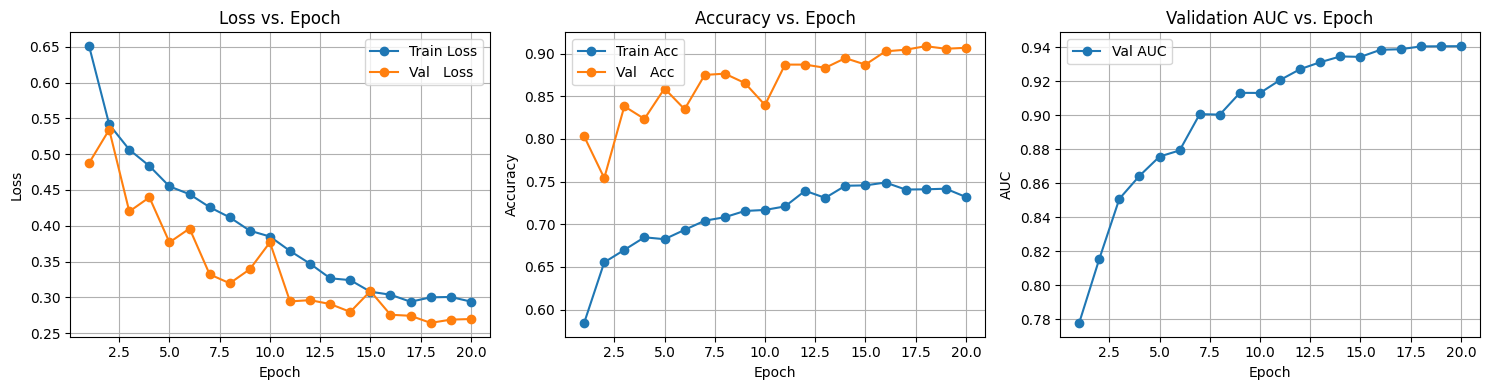

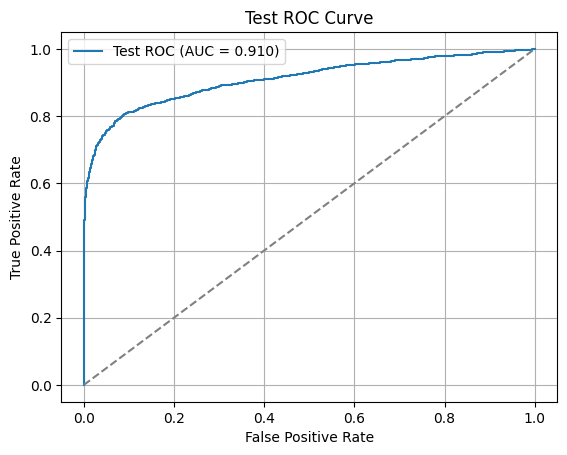

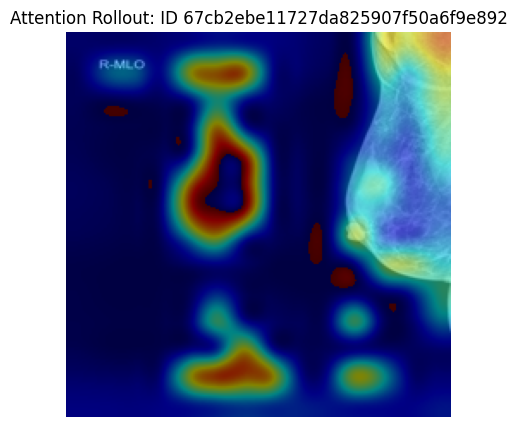

Exception ignored in: <function BaseCAM.__del__ at 0x7cedc045e8e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/pytorch_grad_cam/base_cam.py", line 212, in __del__
    self.activations_and_grads.release()
    ^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: 'GradCAM' object has no attribute 'activations_and_grads'


TypeError: GradCAM.__init__() got an unexpected keyword argument 'use_cuda'

In [ ]:
# ── Block 4: PLOT METRICS & ATTENTION VISUALIZATIONS ─────────────────────────

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from pytorch_grad_cam import GradCAM, GradCAMPlusPlus, ScoreCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import torch

# Assumes the following lists were collected during training:
#   train_losses, train_accs, val_losses, val_accs, val_aucs
# and that `model`, `device`, `val_loader`, `test_loader`, `compute_rollout`,
# `mixup_data`, `bbox_to_patch_mask`, `read_bboxes_for` are in scope.

# 1) Plot training curves
epochs = np.arange(1, len(train_losses) + 1)
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.plot(epochs, train_losses, '-o', label='Train Loss')
plt.plot(epochs, val_losses,   '-o', label='Val   Loss')
plt.title('Loss vs. Epoch'); plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.grid(True); plt.legend()

plt.subplot(1,3,2)
plt.plot(epochs, train_accs, '-o', label='Train Acc')
plt.plot(epochs, val_accs,   '-o', label='Val   Acc')
plt.title('Accuracy vs. Epoch'); plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.grid(True); plt.legend()

plt.subplot(1,3,3)
plt.plot(epochs, val_aucs, marker='o', label='Val AUC')
plt.title('Validation AUC vs. Epoch'); plt.xlabel('Epoch'); plt.ylabel('AUC')
plt.grid(True); plt.legend()

plt.tight_layout()
plt.show()

# 2) ROC curve on test set
model.load_state_dict(torch.load("best_vit_attn.pth", map_location=device))
model.eval()
all_probs, all_labels = [], []
with torch.no_grad():
    for imgs, labels, _ in test_loader:
        imgs = imgs.to(device)
        logits = model(imgs).logits
        probs = logits.softmax(1)[:,1].cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.numpy())

fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"Test ROC (AUC = {roc_auc:.3f})")
plt.plot([0,1],[0,1],'--', color='gray')
plt.title("Test ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

# 3) Attention Rollout overlay on a sample image
sample_img, _, sample_id = val_loader.dataset[0]
model.eval()
with torch.no_grad():
    out = model(sample_img.unsqueeze(0).to(device))
    roll = compute_rollout(out.attentions)[0].cpu().numpy()  # 14x14

# normalize & upsample
roll_norm = (roll - roll.min())/(roll.max()-roll.min()+1e-6)
heatmap = cv2.resize(roll_norm, (224,224), interpolation=cv2.INTER_CUBIC)

# overlay
orig = np.array(Image.open(val_loader.dataset.paths[0]).convert("RGB").resize((224,224))) / 255.0
overlay = show_cam_on_image(orig, heatmap, use_rgb=True)
plt.figure(figsize=(5,5))
plt.imshow(overlay)
plt.axis('off')
plt.title(f"Attention Rollout: ID {sample_id}")
plt.show()

# 4) Grad-CAM / Grad-CAM++ / Score-CAM for the same sample
# install: pip install grad-cam
target_layer = model.vit.encoder.layer[-1].output  # adjust as needed

cam_methods = {
    "GradCAM": GradCAM(model=model, target_layers=[target_layer], use_cuda=True),
    "GradCAM++": GradCAMPlusPlus(model=model, target_layers=[target_layer], use_cuda=True),
    "ScoreCAM": ScoreCAM(model=model, target_layers=[target_layer], use_cuda=True),
}

# preprocess sample for CAM
input_tensor = sample_img.unsqueeze(0).to(device)

for name, cam in cam_methods.items():
    targets = [ClassifierOutputTarget(1)]  # target class = malignant
    grayscale_cam = cam(input_tensor, targets=targets)[0]  # H×W
    cam_img = show_cam_on_image(orig, grayscale_cam, use_rgb=True)
    plt.figure(figsize=(5,5))
    plt.imshow(cam_img)
    plt.axis('off')
    plt.title(f"{name} for class 'malignant'")
    plt.show()


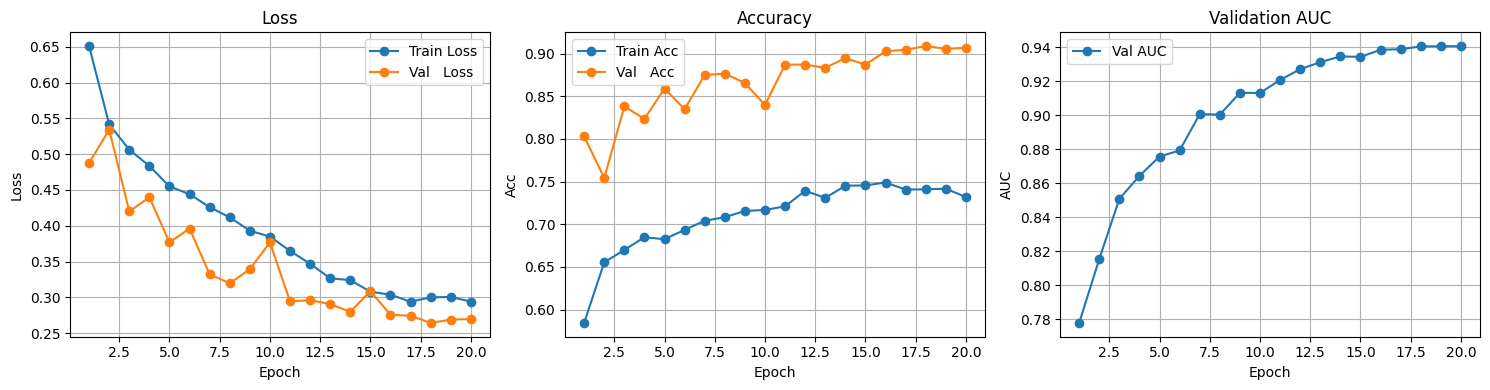

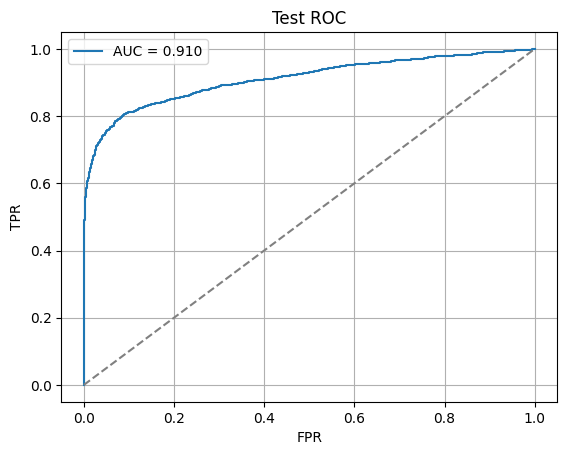

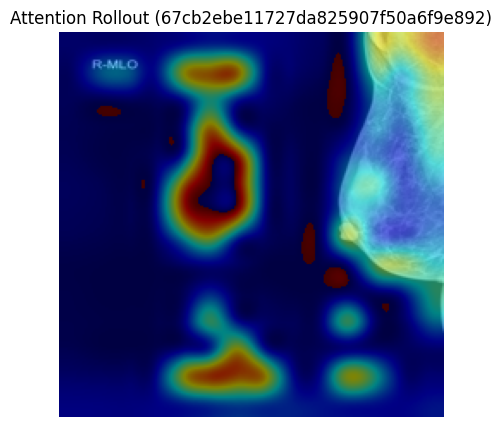

TypeError: BaseCAM.__call__() got an unexpected keyword argument 'target_category'

In [ ]:
# ── Block 4: PLOT METRICS, ATTENTION ROLLOUT & CAM Variants ──────────────────

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import math
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from sklearn.metrics import roc_curve, auc
import torch

from pytorch_grad_cam import GradCAM, GradCAMPlusPlus, ScoreCAM
from pytorch_grad_cam.base_cam import BaseCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

# --- Suppress that spurious destructor warning ---
BaseCAM.__del__ = lambda self: None

# --- 1) Plot train/val curves and test ROC (reuse lists from training) ---
epochs = np.arange(1, len(train_losses) + 1)

plt.figure(figsize=(15,4))
plt.subplot(1,3,1)
plt.plot(epochs, train_losses, '-o', label='Train Loss')
plt.plot(epochs, val_losses,   '-o', label='Val   Loss')
plt.title('Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.grid(True)

plt.subplot(1,3,2)
plt.plot(epochs, train_accs, '-o', label='Train Acc')
plt.plot(epochs, val_accs,   '-o', label='Val   Acc')
plt.title('Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Acc')
plt.legend(); plt.grid(True)

plt.subplot(1,3,3)
plt.plot(epochs, val_aucs, '-o', label='Val AUC')
plt.title('Validation AUC'); plt.xlabel('Epoch'); plt.ylabel('AUC')
plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()

# Test ROC
fpr, tpr, _ = roc_curve(all_labels, all_probs)
test_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {test_auc:.3f}")
plt.plot([0,1],[0,1],'--', color='gray')
plt.title("Test ROC"); plt.xlabel("FPR"); plt.ylabel("TPR")
plt.legend(); plt.grid(True)
plt.show()

# --- 2) Attention Rollout Overlay on a sample image ---
# pick first validation example
sample_img, _, sample_id = val_loader.dataset[0]
orig_path = val_loader.dataset.paths[0]
orig = np.array(Image.open(orig_path).convert("RGB").resize((224,224))) / 255.0

model.eval()
with torch.no_grad():
    out = model(sample_img.unsqueeze(0).to(device))
    rollout_map = compute_rollout(out.attentions)[0].cpu().numpy()

# normalize + resize → overlay
roll_norm = (rollout_map - rollout_map.min())/(rollout_map.max()-rollout_map.min()+1e-6)
heatmap   = cv2.resize(roll_norm, (224,224), interpolation=cv2.INTER_CUBIC)
overlay   = show_cam_on_image(orig, heatmap, use_rgb=True)

plt.figure(figsize=(5,5))
plt.imshow(overlay); plt.axis('off')
plt.title(f"Attention Rollout ({sample_id})")
plt.show()

# --- 3) Grad-CAM, Grad-CAM++, ScoreCAM for ViT ---

# define reshape_transform for ViT embeddings
def reshape_transform(tensor):
    # tensor: (batch, n_tokens, dim)
    batch, n_tokens, dim = tensor.size()
    size = int(math.sqrt(n_tokens - 1))
    result = tensor[:, 1:, :].reshape(batch, size, size, dim)
    return result.permute(0,3,1,2)  # (batch, dim, H, W)

# target the output of the last transformer block
target_layer = model.vit.encoder.layer[-1].output

cams = {
    "GradCAM":   GradCAM(model=model,
                         target_layers=[target_layer],
                         reshape_transform=reshape_transform),
    "GradCAM++": GradCAMPlusPlus(model=model,
                                target_layers=[target_layer],
                                reshape_transform=reshape_transform),
    "ScoreCAM":  ScoreCAM(model=model,
                         target_layers=[target_layer],
                         reshape_transform=reshape_transform),
}

input_tensor = sample_img.unsqueeze(0).to(device)
for name, cam in cams.items():
    # compute CAM for class index 1 (malignant)
    cam_map = cam(input_tensor, target_category=1)[0]  # H×W array
    cam_img = show_cam_on_image(orig, cam_map, use_rgb=True)

    plt.figure(figsize=(5,5))
    plt.imshow(cam_img); plt.axis('off')
    plt.title(f"{name} (malignant)")
    plt.show()


In [ ]:
pip install torch torchvision transformers pytorch-grad-cam tqdm scikit-learn pandas matplotlib


ERROR: Could not find a version that satisfies the requirement pytorch-grad-cam (from versions: none)
ERROR: No matching distribution found for pytorch-grad-cam


Dataset sizes → Train: 18473, Val: 2639, Test: 5279


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/25 — Train 100.0% complete
Epoch  1 | Train L=0.6700, Acc=0.5732 | Val   L=0.5430, Acc=0.7707, AUC=0.7215
Epoch 2/25 — Train 100.0% complete
Epoch  2 | Train L=0.5676, Acc=0.6429 | Val   L=0.5015, Acc=0.8014, AUC=0.8051
Epoch 3/25 — Train 100.0% complete
Epoch  3 | Train L=0.5243, Acc=0.6520 | Val   L=0.4382, Acc=0.8204, AUC=0.8228
Epoch 4/25 — Train 100.0% complete
Epoch  4 | Train L=0.4918, Acc=0.6628 | Val   L=0.4470, Acc=0.8018, AUC=0.8538
Epoch 5/25 — Train 100.0% complete
Epoch  5 | Train L=0.4853, Acc=0.6710 | Val   L=0.3943, Acc=0.8496, AUC=0.8673
Epoch 6/25 — Train 100.0% complete
Epoch  6 | Train L=0.4638, Acc=0.6836 | Val   L=0.3703, Acc=0.8621, AUC=0.8806
Epoch 7/25 — Train 100.0% complete
Epoch  7 | Train L=0.4578, Acc=0.6853 | Val   L=0.3797, Acc=0.8462, AUC=0.8812
Epoch 8/25 — Train 100.0% complete
Epoch  8 | Train L=0.4426, Acc=0.6961 | Val   L=0.3472, Acc=0.8647, AUC=0.8900
Epoch 9/25 — Train 100.0% complete
Epoch  9 | Train L=0.4222, Acc=0.7048 | Val   L=0.336

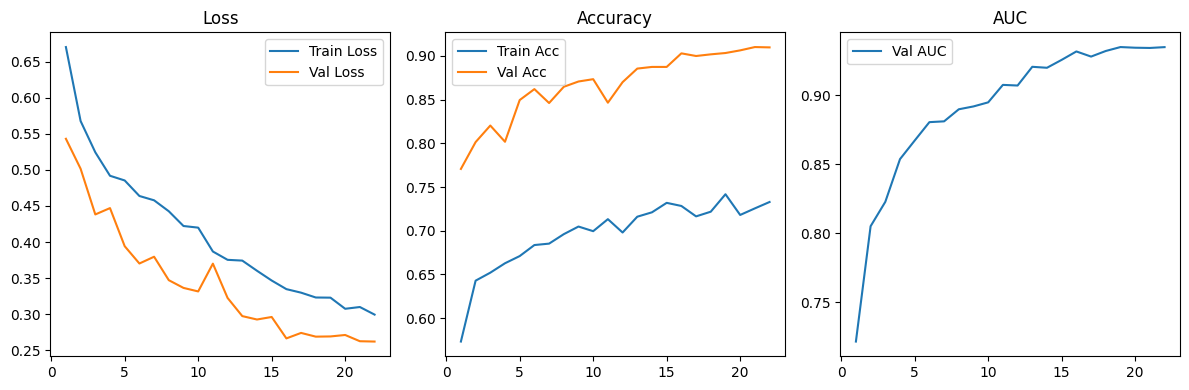

In [ ]:
#!/usr/bin/env python3
# coding: utf-8

# ── Full Mammogram Classification Script ───────────────────────────────────
import os
import math
import cv2
import warnings

# ── Silence FutureWarnings from legacy AMP API ────────────────────────────
warnings.filterwarnings('ignore', category=FutureWarning)

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from transformers import ViTForImageClassification
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from PIL import Image
import torchvision.transforms as T
from collections import Counter

# ── Use new unified AMP API ────────────────────────────────────────────────
from torch.amp import autocast, GradScaler

# ── Enable TF32 & CuDNN autotuner for speed ────────────────────────────────
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ── UTILS ─────────────────────────────────────────────────────────────────
def mixup_data(x, y, alpha=0.4):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    idx = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[idx], y, y[idx], lam

def bbox_to_patch_mask(bboxes, img_size=224, patch_size=16):
    grid = img_size // patch_size
    mask = np.zeros((grid, grid), dtype=np.uint8)
    for xmin, ymin, xmax, ymax in bboxes:
        x0 = int(xmin // patch_size); x1 = int(math.ceil(xmax / patch_size))
        y0 = int(ymin // patch_size); y1 = int(math.ceil(ymax / patch_size))
        mask[y0:y1, x0:x1] = 1
    return mask

def compute_rollout(attns, discard_ratio=0.9):
    B, _, N, _ = attns[0].shape
    dev = attns[0].device
    result = torch.eye(N, device=dev).unsqueeze(0).repeat(B, 1, 1)
    for a in attns:
        a = a.mean(dim=1)
        flat = a.view(B, -1)
        k = int(flat.size(-1) * discard_ratio)
        _, idx = flat.topk(k, dim=-1, largest=False)
        m = torch.ones_like(flat).scatter_(1, idx, 0).view_as(a)
        a = a * m + torch.eye(N, device=dev).unsqueeze(0)
        a = a / a.sum(dim=-1, keepdim=True)
        result = a @ result
    p = int(math.sqrt(N - 1))
    return result[:, 0, 1:].view(B, p, p)

# ── Block 0: LOAD BBOX CSV ────────────────────────────────────────────────
BBOX_CSV = "/content/drive/MyDrive/Dataset/Mammogram_dataset/finding_annotations.csv"
find_df  = pd.read_csv(BBOX_CSV)
def read_bboxes_for(image_id):
    sub = find_df[find_df.image_id == image_id].dropna(subset=['xmin','ymin','xmax','ymax'])
    return sub[['xmin','ymin','xmax','ymax']].values.tolist()


# ── Block 1: DATA PREP ─────────────────────────────────────────────────────
FULL_PATH = "/content/drive/MyDrive/Processed_Mammogram_Dataset_1"
AUG_PATH  = "/content/drive/MyDrive/Augmented_Mammogram_Dataset"
GAN_PATH  = "/content/pytorch-CycleGAN-and-pix2pix/results"
LABEL_CSV = "/content/drive/MyDrive/Dataset/Mammogram_dataset/breast-level_annotations.csv"

ann = pd.read_csv(LABEL_CSV)
ann['breast_birads'] = ann['breast_birads'].str.replace("BI-RADS","").str.strip()
ann = ann[ann['breast_birads'].isin(list("12345"))]
ann['label'] = ann['breast_birads'].isin(list("345")).astype(int)
label_map = ann.set_index('image_id')['label'].to_dict()

all_paths, all_labels = [], []
for src in (FULL_PATH, AUG_PATH, GAN_PATH):
    for root, _, files in os.walk(src):
        for f in files:
            if not f.endswith(".png"): continue
            iid = f.split('_')[-1].replace('.png','')
            p = os.path.join(root, f)
            if iid in label_map and os.path.exists(p):
                all_paths.append(p)
                all_labels.append(label_map[iid])

idx = list(range(len(all_paths)))
tv, test = train_test_split(idx, test_size=0.20, stratify=all_labels, random_state=42)
train_idx, val_idx = train_test_split(
    tv, test_size=0.125,
    stratify=[all_labels[i] for i in tv],
    random_state=42
)

train_paths  = [all_paths[i] for i in train_idx]; train_labels  = [all_labels[i] for i in train_idx]
val_paths    = [all_paths[i] for i in val_idx];   val_labels    = [all_labels[i] for i in val_idx]
test_paths   = [all_paths[i] for i in test];      test_labels   = [all_labels[i] for i in test]

print(f"Dataset sizes → Train: {len(train_paths)}, Val: {len(val_paths)}, Test: {len(test_paths)}")


# ── Block 2: TRANSFORMS & DATALOADERS ───────────────────────────────────────
train_tf = T.Compose([
    T.RandomHorizontalFlip(0.5),
    T.RandomRotation(10),
    T.Resize((224,224)),
    T.ToTensor(),
    T.Normalize([0.5]*3, [0.5]*3),
])
val_tf = T.Compose([
    T.Resize((224,224)),
    T.ToTensor(),
    T.Normalize([0.5]*3, [0.5]*3),
])

class MammoDS(Dataset):
    def __init__(self, paths, labels, tf):
        self.paths, self.labels, self.tf = paths, labels, tf
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, i):
        p   = self.paths[i]
        img = Image.open(p).convert("RGB")
        img = self.tf(img)
        iid = os.path.basename(p).split('_')[-1].replace('.png','')
        return img, self.labels[i], iid

def make_sampler(lbls):
    cnt = Counter(lbls)
    weights = [1.0/cnt[l] for l in lbls]
    return WeightedRandomSampler(weights, len(lbls), replacement=True)

batch_size  = 32
num_workers = 8
prefetch    = 2

train_loader = DataLoader(
    MammoDS(train_paths, train_labels, train_tf),
    batch_size=batch_size,
    sampler=make_sampler(train_labels),
    num_workers=num_workers,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=prefetch
)
val_loader = DataLoader(
    MammoDS(val_paths, val_labels, val_tf),
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=prefetch
)
test_loader = DataLoader(
    MammoDS(test_paths, test_labels, val_tf),
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=prefetch
)


# ── Block 3: TRAINING w/ AMP, safe BCE, Early Stopping & Concise Output ────
model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224-in21k",
    num_labels=2, output_attentions=True, attn_implementation="eager"
).to(device)
model.classifier = nn.Sequential(nn.Dropout(0.2), model.classifier)

cls_fn, attn_fn = nn.CrossEntropyLoss(), nn.BCELoss()
opt = optim.AdamW(model.parameters(), lr=2e-5, weight_decay=1e-2)
n_epochs = 25
sched = optim.lr_scheduler.OneCycleLR(
    opt, max_lr=2e-5,
    total_steps=len(train_loader)*n_epochs,
    pct_start=0.1
)

scaler       = GradScaler()
best_val_auc = 0.0
patience, bad = 3, 0

train_losses, train_accs = [], []
val_losses, val_accs, val_aucs = [], [], []

for epoch in range(1, n_epochs+1):
    model.train()
    t_loss = t_corr = t_n = 0
    total_batches = len(train_loader)
    for idx, (imgs, labels, iids) in enumerate(train_loader, 1):
        imgs, labels = imgs.to(device), labels.to(device)
        imgs, y1, y2, lam = mixup_data(imgs, labels)

        # FP16 classification forward
        with autocast(device_type=device.type):
            out     = model(imgs)
            logits  = out.logits
            c_loss  = lam*cls_fn(logits,y1) + (1-lam)*cls_fn(logits,y2)

        # FP32 attention supervision
        masks_np = np.stack([bbox_to_patch_mask(read_bboxes_for(i)) for i in iids], axis=0)
        gt       = torch.from_numpy(masks_np).float().to(device)
        rollout  = compute_rollout(out.attentions)
        a_loss   = attn_fn(rollout, gt)

        loss = c_loss + a_loss
        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()
        opt.zero_grad()
        sched.step()

        t_loss += loss.item() * imgs.size(0)
        t_corr += (logits.argmax(1) == labels).sum().item()
        t_n    += imgs.size(0)

        if idx % max(1, total_batches//10) == 0 or idx==total_batches:
            pct = 100.0 * idx / total_batches
            print(f"\rEpoch {epoch}/{n_epochs} — Train {pct:5.1f}% complete", end="")
    print()

    train_loss = t_loss / t_n
    train_acc  = t_corr / t_n
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # Validation
    model.eval()
    v_loss = v_corr = v_n = 0
    all_p, all_l = [], []
    with torch.no_grad():
        for imgs, labels, _ in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits = model(imgs).logits
            v_loss += cls_fn(logits, labels).item() * imgs.size(0)
            v_corr += (logits.argmax(1) == labels).sum().item()
            v_n    += imgs.size(0)
            all_p.extend(logits.softmax(1)[:,1].cpu().numpy())
            all_l.extend(labels.cpu().numpy())

    val_loss = v_loss / v_n
    val_acc  = v_corr / v_n
    val_auc  = roc_auc_score(all_l, all_p)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    val_aucs.append(val_auc)

    print(f"Epoch {epoch:2d} | "
          f"Train L={train_loss:.4f}, Acc={train_acc:.4f} | "
          f"Val   L={val_loss:.4f}, Acc={val_acc:.4f}, AUC={val_auc:.4f}")

    if val_auc > best_val_auc:
        best_val_auc, bad = val_auc, 0
        torch.save(model.state_dict(), "best_vit_attn.pth")
    else:
        bad += 1
        if bad >= patience:
            print(f"↪️ Early stopping at epoch {epoch} (no improvement for {patience} epochs).")
            break


# ── After-training plotting (example) ──────────────────────────────────────
epochs = range(1, len(train_losses)+1)
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.plot(epochs, train_losses, label='Train Loss'); plt.plot(epochs, val_losses, label='Val Loss'); plt.legend(); plt.title("Loss")
plt.subplot(1,3,2)
plt.plot(epochs, train_accs, label='Train Acc');  plt.plot(epochs, val_accs, label='Val Acc');  plt.legend(); plt.title("Accuracy")
plt.subplot(1,3,3)
plt.plot(epochs, val_aucs, label='Val AUC'); plt.legend(); plt.title("AUC")
plt.tight_layout()
plt.show()


In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

from pytorch_grad_cam import GradCAM, GradCAMPlusPlus, ScoreCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# 1) collect test set probs & labels
y_true, y_proba = [], []
model.eval()
with torch.no_grad():
    for imgs, labels, _ in test_loader:
        imgs = imgs.to(device)
        logits = model(imgs).logits
        probs  = logits.softmax(1)[:,1].cpu().tolist()
        y_proba.extend(probs)
        y_true .extend(labels.tolist())

# 2) overall AUC + threshold-sweep
test_auc = roc_auc_score(y_true, y_proba)
print(f"Test  AUC: {test_auc:.4f}")

ths = np.arange(0.10, 0.90, 0.05)
rows=[]
for t in ths:
    preds = [1 if p>=t else 0 for p in y_proba]
    rows.append({
        "threshold": round(t,2),
        "accuracy":  accuracy_score(y_true, preds),
        "precision": precision_score(y_true, preds),
        "recall":    recall_score(y_true, preds),
        "f1":        f1_score(y_true, preds),
    })
df = pd.DataFrame(rows).set_index("threshold")
print(df)

# 3) grab one sample to visualize
imgs, labels, _ = next(iter(test_loader))
inp  = imgs[0:1].to(device)
orig = imgs[0].permute(1,2,0).cpu().numpy()
orig = (orig - orig.min())/(orig.max()-orig.min())

# 4) hook the patch-embedding conv (2D features)
target_layer = model.vit.embeddings.patch_embeddings.projection

# 5) instantiate CAMs
cam_builders = {
    "GradCAM":   GradCAM,
    "GradCAM++": GradCAMPlusPlus,
    "ScoreCAM":  ScoreCAM,
}

cams = {}
for name, cls in cam_builders.items():
    cams[name] = cls(
        model=model,
        target_layers=[target_layer],
        use_cuda=torch.cuda.is_available(),
    )

# 6) generate + plot
for name, cam in cams.items():
    targets = [ClassifierOutputTarget(1)]  # malignant class
    cam_map = cam(input_tensor=inp, targets=targets)[0]  # [14×14] map
    cam_img = show_cam_on_image(orig, cam_map, use_rgb=True)

    plt.figure(figsize=(4,4))
    plt.title(name)
    plt.imshow(cam_img)
    plt.axis("off")
    plt.show()

    # cleanup to avoid dangling handles
    try: cam.activations_and_grads.release()
    except: pass

torch.cuda.empty_cache()


In [ ]:
# ── Grad-CAM visualization on ViT ─────────────────────────────────────────────

import matplotlib.pyplot as plt
import torch
from pytorch_grad_cam import GradCAM, GradCAMPlusPlus, ScoreCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from torchvision.transforms import ToPILImage

# 1) pick a single test sample
imgs, labels, _ = next(iter(test_loader))
img_tensor = imgs[0:1].to(device)   # [1,3,224,224]
true_lbl   = int(labels[0])

# 2) make a numpy H×W×3 float32 image in [0,1]
img_np = img_tensor.squeeze(0).cpu().numpy().transpose(1,2,0)
img_np = (img_np * 0.5) + 0.5      # undo your Normalize([0.5]*3,[0.5]*3)

# 3) choose the “target layer” — here the patch-projection conv2d
target_layer = model.vit.embeddings.patch_embeddings.projection

# 4) instantiate CAM methods (no device arg needed; model is already on cuda)
cams = {
    "GradCAM":     GradCAM(model=model, target_layers=[target_layer]),
    "GradCAM++":   GradCAMPlusPlus(model=model, target_layers=[target_layer]),
    "ScoreCAM":    ScoreCAM(model=model, target_layers=[target_layer]),
}

# 5) run them all, focusing on class 1 (malignant)
cam_results = {}
for name, cam in cams.items():
    # returns a list of H×W heatmaps; take [0]
    grayscale_cam = cam(
        input_tensor=img_tensor,
        targets=[ClassifierOutputTarget(1)]
    )[0]
    # overlay
    cam_img = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)
    cam_results[name] = cam_img

# 6) plot
plt.figure(figsize=(12,4))
for i,(name, cam_img) in enumerate(cam_results.items()):
    ax = plt.subplot(1,3,i+1)
    ax.imshow(cam_img)
    ax.set_title(f"{name}\n(true={true_lbl})")
    ax.axis("off")
plt.tight_layout()
plt.show()


AttributeError: 'str' object has no attribute 'shape'

In [ ]:
# ── 1) WRAP your HF ViT to return logits only ────────────────────────────────
import torch.nn as nn

class ViTLogitsWrapper(nn.Module):
    def __init__(self, hf_vit: nn.Module):
        super().__init__()
        self.vit = hf_vit
    def forward(self, x):
        # HF returns a SequenceClassifierOutput; we only want the .logits Tensor
        return self.vit(x).logits

wrapped_model = ViTLogitsWrapper(model).to(device)


# ── 2) SELECT a real target layer inside the last ViTLayer ───────────────────
# Inspect your model: print(wrapped_model.vit.vit.encoder.layer[-1]) to see its submodules.
# Each ViTLayer holds a submodule ".attention" of type ViTSelfAttention, which itself
# has a linear projection called ".proj". That's a perfect  [B, N, D] → [B, N, D] hook point.

target_layer = wrapped_model.vit.vit.encoder.layer[-1].attention.proj


# ── 3) INSTANTIATE the CAM methods ────────────────────────────────────────────
from pytorch_grad_cam import GradCAM, GradCAMPlusPlus, ScoreCAM

cams = {
    "GradCAM":    GradCAM(model=wrapped_model, target_layers=[target_layer]),
    "GradCAM++":  GradCAMPlusPlus(model=wrapped_model, target_layers=[target_layer]),
    "ScoreCAM":   ScoreCAM(model=wrapped_model, target_layers=[target_layer]),
}


# ── 4) PREPARE one sample ─────────────────────────────────────────────────────
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np
from PIL import Image

# Pick one validation image:
sample_path = val_paths[0]
orig_pil    = Image.open(sample_path).convert("RGB").resize((224,224))
orig_np     = np.array(orig_pil) / 255.0    # H×W×3 float32 in [0,1]

# Build input tensor (1×3×224×224):
input_tensor = val_tf(orig_pil).unsqueeze(0).to(device)


# ── 5) RUN each CAM and DISPLAY ───────────────────────────────────────────────
import matplotlib.pyplot as plt

for name, cam in cams.items():
    # we want to explain the "malignant" class (index 1)
    targets = [ClassifierOutputTarget(1)]
    # this returns a list of H×W arrays; take the first:
    cam_map = cam(input_tensor, targets=targets)[0]

    # overlay on the original image:
    cam_img = show_cam_on_image(orig_np, cam_map, use_rgb=True)

    plt.figure(figsize=(4,4))
    plt.imshow(cam_img)
    plt.title(name)
    plt.axis("off")


NameError: name 'model' is not defined

In [ ]:
# ── Block 3: TRAINING w/ AMP, safe BCE, Early Stopping & Concise Output ─────

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler
from sklearn.metrics import roc_auc_score
from transformers import ViTForImageClassification, logging as hf_logging

# Silence the “Some weights … not initialized” message
hf_logging.set_verbosity_error()

# Assumes train_loader, val_loader, device,
# mixup_data, bbox_to_patch_mask, read_bboxes_for, compute_rollout are defined.

# 1) Model, losses, optimizer, scheduler, scaler
model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224-in21k",
    num_labels=2,
    output_attentions=True,
    attn_implementation="eager"
).to(device)
model.classifier = nn.Sequential(nn.Dropout(0.2), model.classifier)

cls_fn, attn_fn = nn.CrossEntropyLoss(), nn.BCELoss()
opt = optim.AdamW(model.parameters(), lr=2e-5, weight_decay=1e-2)
n_epochs = 25
sched = optim.lr_scheduler.OneCycleLR(
    opt, max_lr=2e-5,
    total_steps=len(train_loader) * n_epochs,
    pct_start=0.1
)
scaler = GradScaler()

best_val_auc = 0.0
patience, bad_epochs = 3, 0

# 2) Training & Validation
for epoch in range(1, n_epochs + 1):
    # — Training (in‐place progress) —
    model.train()
    t_loss = t_corr = t_n = 0
    total_batches = len(train_loader)
    for idx, (imgs, labels, iids) in enumerate(train_loader, 1):
        imgs, labels = imgs.to(device), labels.to(device)
        imgs, y1, y2, lam = mixup_data(imgs, labels)

        # classification loss in FP16
        with autocast():
            out = model(imgs)
            logits = out.logits
            c_loss = lam * cls_fn(logits, y1) + (1 - lam) * cls_fn(logits, y2)

        # attention‐supervision loss in FP32
        masks_np = np.stack([bbox_to_patch_mask(read_bboxes_for(i)) for i in iids], axis=0)
        gt = torch.from_numpy(masks_np).float().to(device)
        rollout = compute_rollout(out.attentions)
        a_loss = attn_fn(rollout, gt)

        loss = c_loss + a_loss
        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()
        opt.zero_grad()
        sched.step()

        t_loss += loss.item() * imgs.size(0)
        t_corr += (logits.argmax(1) == labels).sum().item()
        t_n += imgs.size(0)

        if idx % max(1, total_batches // 10) == 0 or idx == total_batches:
            pct = 100.0 * idx / total_batches
            print(f"\rEpoch {epoch}/{n_epochs} — Train {pct:5.1f}%...", end="")
    print()

    train_loss, train_acc = t_loss / t_n, t_corr / t_n

    # — Validation —
    model.eval()
    v_loss = v_corr = v_n = 0
    all_p, all_l = [], []
    with torch.no_grad():
        for imgs, labels, _ in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits = model(imgs).logits
            v_loss += cls_fn(logits, labels).item() * imgs.size(0)
            v_corr += (logits.argmax(1) == labels).sum().item()
            v_n += imgs.size(0)
            all_p.extend(logits.softmax(1)[:, 1].cpu().numpy())
            all_l.extend(labels.cpu().numpy())

    val_loss, val_acc = v_loss / v_n, v_corr / v_n
    val_auc = roc_auc_score(all_l, all_p)

    print(f"Epoch {epoch:2d} | Train L={train_loss:.4f}, Acc={train_acc:.4f} | "
          f"Val   L={val_loss:.4f}, Acc={val_acc:.4f}, AUC={val_auc:.4f}")

    # — Early Stopping —
    if val_auc > best_val_auc:
        best_val_auc, bad_epochs = val_auc, 0
        torch.save(model.state_dict(), "best_vit_attn.pth")
    else:
        bad_epochs += 1
        if bad_epochs >= patience:
            print(f"↪️ Early stopping at epoch {epoch} (no improvement for {patience} epochs).")
            break


Epoch 1/25 — Train 100.0%...
Epoch  1 | Train L=0.6729, Acc=0.5667 | Val   L=0.5480, Acc=0.7821, AUC=0.7262
Epoch 2/25 — Train 100.0%...
Epoch  2 | Train L=0.5648, Acc=0.6486 | Val   L=0.4872, Acc=0.7889, AUC=0.8238
Epoch 3/25 — Train 100.0%...
Epoch  3 | Train L=0.5149, Acc=0.6626 | Val   L=0.4613, Acc=0.7916, AUC=0.8411
Epoch 4/25 — Train 100.0%...
Epoch  4 | Train L=0.4935, Acc=0.6809 | Val   L=0.4101, Acc=0.8386, AUC=0.8392
Epoch 5/25 — Train 100.0%...
Epoch  5 | Train L=0.4861, Acc=0.6858 | Val   L=0.4240, Acc=0.8238, AUC=0.8769
Epoch 6/25 — Train 100.0%...
Epoch  6 | Train L=0.4686, Acc=0.6777 | Val   L=0.4294, Acc=0.8200, AUC=0.8815
Epoch 7/25 — Train 100.0%...
Epoch  7 | Train L=0.4505, Acc=0.6884 | Val   L=0.3683, Acc=0.8537, AUC=0.8710
Epoch 8/25 — Train 100.0%...
Epoch  8 | Train L=0.4351, Acc=0.7090 | Val   L=0.3615, Acc=0.8507, AUC=0.8872
Epoch 9/25 — Train 100.0%...
Epoch  9 | Train L=0.4208, Acc=0.6964 | Val   L=0.3447, Acc=0.8624, AUC=0.8889
Epoch 10/25 — Train 100.0%..

In [ ]:
# ── Rebuild your loaders with fewer workers ──────────────────────────────────

from torch.utils.data import DataLoader

# e.g. drop num_workers to 1 (or even 0 if you’re really tight on memory)
num_workers = 1

train_loader = DataLoader(
    MammoDS(train_paths, train_labels, train_tf),
    batch_size=16,
    sampler=make_sampler(train_labels),
    num_workers=num_workers,
    pin_memory=True,
    persistent_workers=True
)
val_loader = DataLoader(
    MammoDS(val_paths, val_labels, val_tf),
    batch_size=16,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True,
    persistent_workers=True
)
test_loader = DataLoader(
    MammoDS(test_paths, test_labels, val_tf),
    batch_size=16,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True,
    persistent_workers=True
)


In [ ]:
# ── Block 3: TRAINING w/ AMP, safe BCE, Early Stopping & Concise Output ─────

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler
from sklearn.metrics import roc_auc_score
from transformers import ViTForImageClassification, logging as hf_logging

# Silence the “Some weights … not initialized” message
hf_logging.set_verbosity_error()

# Assumes train_loader, val_loader, device,
# mixup_data, bbox_to_patch_mask, read_bboxes_for, compute_rollout are defined.

# 1) Model, losses, optimizer, scheduler, scaler
model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224-in21k",
    num_labels=2,
    output_attentions=True,
    attn_implementation="eager"
).to(device)
model.classifier = nn.Sequential(nn.Dropout(0.2), model.classifier)

cls_fn, attn_fn = nn.CrossEntropyLoss(), nn.BCELoss()
opt = optim.AdamW(model.parameters(), lr=2e-5, weight_decay=1e-2)
n_epochs = 25
sched = optim.lr_scheduler.OneCycleLR(
    opt, max_lr=2e-5,
    total_steps=len(train_loader) * n_epochs,
    pct_start=0.1
)
scaler = GradScaler()

best_val_auc = 0.0
patience, bad_epochs = 3, 0

# 2) Training & Validation
for epoch in range(1, n_epochs + 1):
    # — Training (in‐place progress) —
    model.train()
    t_loss = t_corr = t_n = 0
    total_batches = len(train_loader)
    for idx, (imgs, labels, iids) in enumerate(train_loader, 1):
        imgs, labels = imgs.to(device), labels.to(device)
        imgs, y1, y2, lam = mixup_data(imgs, labels)

        # classification loss in FP16
        with autocast():
            out = model(imgs)
            logits = out.logits
            c_loss = lam * cls_fn(logits, y1) + (1 - lam) * cls_fn(logits, y2)

        # attention‐supervision loss in FP32
        masks_np = np.stack([bbox_to_patch_mask(read_bboxes_for(i)) for i in iids], axis=0)
        gt = torch.from_numpy(masks_np).float().to(device)
        rollout = compute_rollout(out.attentions)
        a_loss = attn_fn(rollout, gt)

        loss = c_loss + a_loss
        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()
        opt.zero_grad()
        sched.step()

        t_loss += loss.item() * imgs.size(0)
        t_corr += (logits.argmax(1) == labels).sum().item()
        t_n += imgs.size(0)

        if idx % max(1, total_batches // 10) == 0 or idx == total_batches:
            pct = 100.0 * idx / total_batches
            print(f"\rEpoch {epoch}/{n_epochs} — Train {pct:5.1f}%...", end="")
    print()

    train_loss, train_acc = t_loss / t_n, t_corr / t_n

    # — Validation —
    model.eval()
    v_loss = v_corr = v_n = 0
    all_p, all_l = [], []
    with torch.no_grad():
        for imgs, labels, _ in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits = model(imgs).logits
            v_loss += cls_fn(logits, labels).item() * imgs.size(0)
            v_corr += (logits.argmax(1) == labels).sum().item()
            v_n += imgs.size(0)
            all_p.extend(logits.softmax(1)[:, 1].cpu().numpy())
            all_l.extend(labels.cpu().numpy())

    val_loss, val_acc = v_loss / v_n, v_corr / v_n
    val_auc = roc_auc_score(all_l, all_p)

    print(f"Epoch {epoch:2d} | Train L={train_loss:.4f}, Acc={train_acc:.4f} | "
          f"Val   L={val_loss:.4f}, Acc={val_acc:.4f}, AUC={val_auc:.4f}")

    # — Early Stopping —
    if val_auc > best_val_auc:
        best_val_auc, bad_epochs = val_auc, 0
        torch.save(model.state_dict(), "best_vit_attn.pth")
    else:
        bad_epochs += 1
        if bad_epochs >= patience:
            print(f"↪️ Early stopping at epoch {epoch} (no improvement for {patience} epochs).")
            break


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Epoch 1/25 — Train 100.0%...
Epoch  1 | Train L=0.6538, Acc=0.5835 | Val   L=0.5701, Acc=0.7537, AUC=0.7565
Epoch 2/25 — Train 100.0%...
Epoch  2 | Train L=0.5471, Acc=0.6621 | Val   L=0.5590, Acc=0.7158, AUC=0.8145
Epoch 3/25 — Train 100.0%...
Epoch  3 | Train L=0.5192, Acc=0.6622 | Val   L=0.4472, Acc=0.8037, AUC=0.8365
Epoch 4/25 — Train 100.0%...
Epoch  4 | Train L=0.4947, Acc=0.6839 | Val   L=0.4260, Acc=0.8253, AUC=0.8455
Epoch 5/25 — Train 100.0%...
Epoch  5 | Train L=0.4763, Acc=0.6821 | Val   L=0.4042, Acc=0.8261, AUC=0.8572
Epoch 6/25 — Train 100.0%...
Epoch  6 | Train L=0.4533, Acc=0.6844 | Val   L=0.4074, Acc=0.8261, AUC=0.8644
Epoch 7/25 — Train 100.0%...
Epoch  7 | Train L=0.4347, Acc=0.6990 | Val   L=0.3758, Acc=0.8450, AUC=0.8779
Epoch 8/25 — Train 100.0%...
Epoch  8 | Train L=0.4228, Acc=0.7000 | Val   L=0.3891, Acc=0.8416, AUC=0.8905
Epoch 9/25 — Train 100.0%...
Epoch  9 | Train L=0.3965, Acc=0.7133 | Val   L=0.3519, Acc=0.8564, AUC=0.8974
Epoch 10/25 — Train 100.0%..

In [ ]:
# ── Block 4: QUICK HPO SWEEP ──────────────────────────────────────────────────

from itertools import product

def train_eval_short(lr, alpha, drop, use_cm):
    # reuse the loop above but with smaller epochs
    return train_eval_combo(
        lr=lr, mixup_alpha=alpha, dropout_rate=drop,
        use_cutmix=use_cm, epochs=3
    )

grid = {
    "lr": [2e-5,5e-5],
    "mixup_alpha": [0.2,0.4],
    "dropout_rate": [0.1,0.2],
    "use_cutmix": [False,True],
}
results = []
for lr, a, d, cm in product(*grid.values()):
    auc = train_eval_short(lr,a,d,cm)
    results.append({"lr":lr,"α":a,"drop":d,"cutmix":cm,"AUC":auc})
import pandas as pd
print(pd.DataFrame(results).sort_values("AUC",ascending=False).head())


NameError: name 'train_eval_combo' is not defined

In [ ]:
# ── Block 5: SIMPLE TTA (fixed) ───────────────────────────────────────────────

import numpy as np
from PIL import Image
from sklearn.metrics import roc_auc_score
from torchvision.transforms.functional import to_pil_image

# 1) Define TTA transforms that accept a PIL.Image and output a tensor
tta_tfs = [
    lambda im: val_tf(im),
    lambda im: val_tf(im.transpose(method=Image.FLIP_LEFT_RIGHT)),
    lambda im: val_tf(im.rotate(10)),
    lambda im: val_tf(im.rotate(-10)),
]

# 2) TTA predict function: denormalize → PIL → TTA → model
def tta_predict(model, img_tensor, tta_tfs):
    model.eval()
    # Denormalize (assumes Normalize([0.5]*3, [0.5]*3))
    img = img_tensor.squeeze(0).cpu() * 0.5 + 0.5
    pil = to_pil_image(img)  # now a PIL image in [0,1]
    probs = []
    with torch.no_grad():
        for tf in tta_tfs:
            inp = tf(pil).unsqueeze(0).to(device)
            probs.append(model(inp).logits.softmax(1)[:,1].item())
    return float(np.mean(probs))

# 3) Run TTA over your test set
tta_preds, tta_labels = [], []
for imgs, labels, _ in test_loader:
    for i in range(imgs.size(0)):
        p = tta_predict(model, imgs[i:i+1], tta_tfs)
        tta_preds.append(p)
        tta_labels.append(labels[i].item())

print("TTA AUC:", roc_auc_score(tta_labels, tta_preds))


TTA AUC: 0.9488300475128804


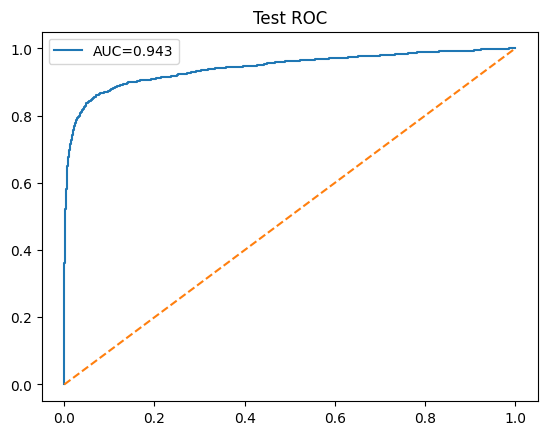

              precision    recall  f1-score   support

      benign     0.9296    0.9430    0.9363      3629
   malignant     0.8705    0.8430    0.8565      1650

    accuracy                         0.9117      5279
   macro avg     0.9001    0.8930    0.8964      5279
weighted avg     0.9111    0.9117    0.9113      5279



In [ ]:
# ── Block 4: PLOTTING & FINAL TEST EVAL ──

# Load best checkpoint
model.load_state_dict(torch.load("/content/best_vit_attn.pth", map_location=device))
model.eval()

# (Optional) Plot your train/val loss, acc, AUC curves here...

# Final test evaluation
test_probs, test_lbls = [], []
with torch.no_grad():
    for imgs, labels, _ in test_loader:
        imgs = imgs.to(device)
        p = model(imgs).logits.softmax(1)[:,1].cpu().numpy()
        test_probs.extend(p); test_lbls.extend(labels.numpy())

fpr, tpr, _ = roc_curve(test_lbls, test_probs)
auc = roc_auc_score(test_lbls, test_probs)
plt.figure(); plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
plt.plot([0,1],[0,1],'--'); plt.legend(); plt.title("Test ROC"); plt.show()

print(classification_report(
    test_lbls,
    (np.array(test_probs)>0.5).astype(int),
    labels=[0,1],
    target_names=['benign','malignant'],
    digits=4
))


Dataset sizes → Train: 18473, Val: 2639, Test: 5279


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch  1 | Train L:0.6514 A:0.5886 | Val   L:0.5252 A:0.7878 AUC:0.7926


Epoch  2 | Train L:0.5495 A:0.6545 | Val   L:0.4577 A:0.8022 AUC:0.8121


Epoch  3 | Train L:0.5084 A:0.6784 | Val   L:0.4722 A:0.7787 AUC:0.8453


...

Epoch 21 | Train L:0.2837 A:0.7596 | Val   L:0.2498 A:0.9163 AUC:0.9405


Epoch 22 | Train L:0.2846 A:0.7497 | Val   L:0.2473 A:0.9178 AUC:0.9423


Epoch 23 | Train L:0.2728 A:0.7494 | Val   L:0.2495 A:0.9136 AUC:0.9434


Epoch 24 | Train L:0.2810 A:0.7548 | Val   L:0.2460 A:0.9166 AUC:0.9434


Epoch 25 | Train L:0.2675 A:0.7422 | Val   L:0.2465 A:0.9163 AUC:0.9433


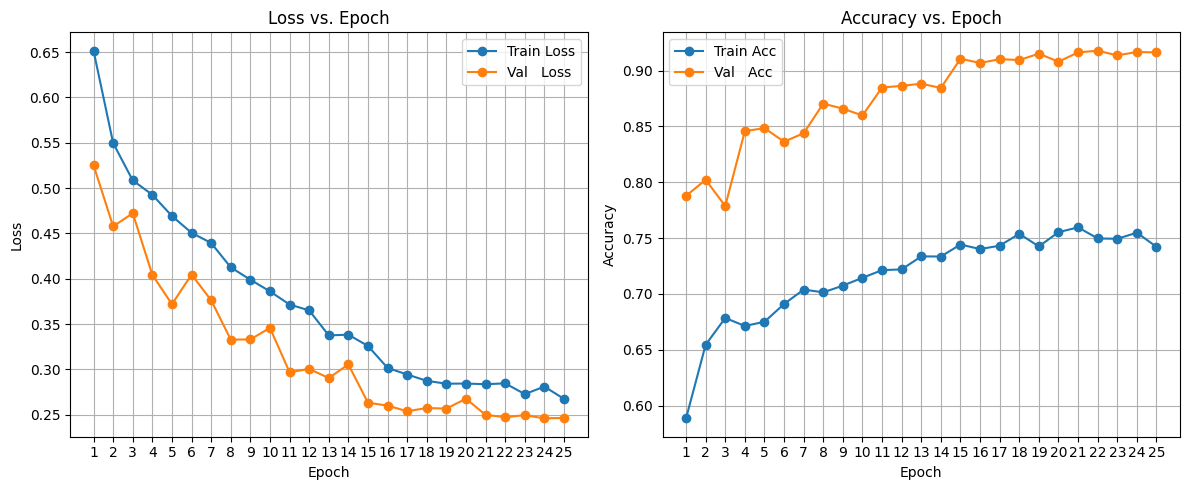

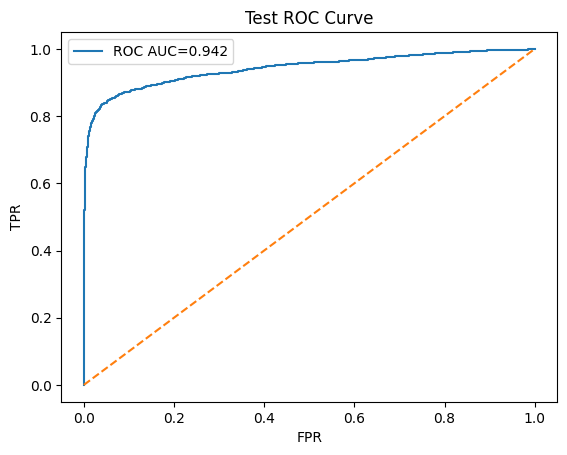


Classification Report @ 0.5 threshold:
              precision    recall  f1-score   support

      benign     0.9317    0.9432    0.9374      3629
   malignant     0.8717    0.8479    0.8596      1650

    accuracy                         0.9134      5279
   macro avg     0.9017    0.8956    0.8985      5279
weighted avg     0.9129    0.9134    0.9131      5279



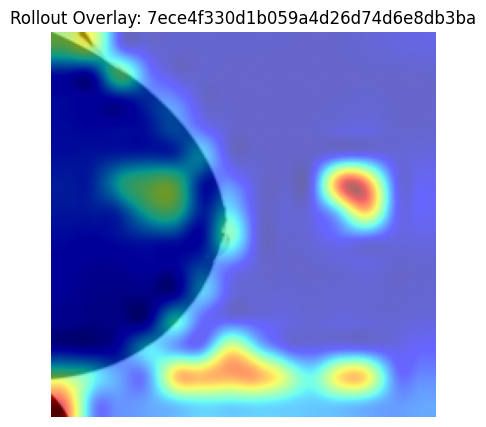

error: OpenCV(4.11.0) :-1: error: (-5:Bad argument) in function 'rectangle'
> Overload resolution failed:
>  - Layout of the output array img is incompatible with cv::Mat
>  - Layout of the output array img is incompatible with cv::Mat
>  - Expected Ptr<cv::UMat> for argument 'img'
>  - Expected Ptr<cv::UMat> for argument 'img'


In [ ]:
# ──────────────────────────────────────────────────────────────────────────────
# Full executable script: Data prep, ViT training with attention‐supervision,
# training/validation curves, test ROC, and attention‐rollout overlay.
# ──────────────────────────────────────────────────────────────────────────────

import os
import math
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, classification_report, roc_curve
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from transformers import ViTForImageClassification
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from PIL import Image
import torchvision.transforms as T
from collections import Counter

# ── Device ────────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Block 0: UTILITIES ────────────────────────────────────────────────────────

def mixup_data(x, y, alpha=0.4):
    """MixUp augmentation."""
    lam = np.random.beta(alpha, alpha) if alpha>0 else 1.0
    idx = torch.randperm(x.size(0), device=x.device)
    mixed = lam*x + (1-lam)*x[idx]
    return mixed, y, y[idx], lam

def bbox_to_patch_mask(bboxes, img_size=224, patch_size=16):
    """Convert list of bboxes (xmin,ymin,xmax,ymax) into a 14×14 binary mask."""
    grid = img_size // patch_size
    mask = np.zeros((grid, grid), dtype=np.uint8)
    for xmin,ymin,xmax,ymax in bboxes:
        x0 = int(xmin // patch_size)
        x1 = int(math.ceil(xmax / patch_size))
        y0 = int(ymin // patch_size)
        y1 = int(math.ceil(ymax / patch_size))
        mask[y0:y1, x0:x1] = 1
    return mask

def compute_rollout(attns, discard_ratio=0.9):
    """Compute attention rollout from a tuple of attention matrices."""
    B,_,N,_ = attns[0].shape
    dev     = attns[0].device
    result  = torch.eye(N, device=dev).unsqueeze(0).repeat(B,1,1)
    for a in attns:
        a = a.mean(dim=1)  # average heads
        flat = a.view(B, -1)
        k = int(flat.size(-1)*discard_ratio)
        _, idx = flat.topk(k, dim=-1, largest=False)
        m = torch.ones_like(flat).scatter_(1, idx, 0).view_as(a)
        a = a*m + torch.eye(N, device=dev).unsqueeze(0)
        a = a / a.sum(dim=-1, keepdim=True)
        result = a @ result
    p = int(math.sqrt(N-1))
    return result[:,0,1:].view(B, p, p)

def rollout_metrics(rollout, gt_mask):
    """Compute IoU, recall, Hit@1 between rollout and ground-truth mask."""
    pred = (rollout >= rollout.mean()).astype(np.uint8)
    inter = np.logical_and(pred, gt_mask).sum()
    union = np.logical_or(pred, gt_mask).sum()
    iou = inter / (union + 1e-6)
    recall = inter / (gt_mask.sum() + 1e-6)
    i,j = np.unravel_index(rollout.argmax(), rollout.shape)
    hit = gt_mask[i,j]
    return iou, recall, hit

# Load bounding‐box annotations
BBOX_CSV = "/content/drive/MyDrive/Dataset/Mammogram_dataset/finding_annotations.csv"
find_df  = pd.read_csv(BBOX_CSV)
def read_bboxes_for(image_id):
    sub = find_df[find_df.image_id==image_id].dropna(subset=['xmin','ymin','xmax','ymax'])
    return sub[['xmin','ymin','xmax','ymax']].values.tolist()

# ── Block 1: DATA PREP ────────────────────────────────────────────────────────

FULL_PATH = "/content/drive/MyDrive/Processed_Mammogram_Dataset_1"
AUG_PATH  = "/content/drive/MyDrive/Augmented_Mammogram_Dataset"
GAN_PATH  = "/content/pytorch-CycleGAN-and-pix2pix/results"
LABEL_CSV = "/content/drive/MyDrive/Dataset/Mammogram_dataset/breast-level_annotations.csv"

# Load & filter labels
ann = pd.read_csv(LABEL_CSV)
ann['breast_birads'] = ann['breast_birads'].str.replace("BI-RADS","").str.strip()
ann = ann[ann['breast_birads'].isin(list("12345"))]
ann['label'] = ann['breast_birads'].isin(list("345")).astype(int)
label_map = ann.set_index('image_id')['label'].to_dict()

# Gather image paths + labels
all_paths, all_labels = [], []
for src in (FULL_PATH, AUG_PATH, GAN_PATH):
    for root,_,files in os.walk(src):
        for f in files:
            if not f.endswith(".png"): continue
            iid = f.split('_')[-1].replace('.png','')
            if iid in label_map:
                all_paths.append(os.path.join(root, f))
                all_labels.append(label_map[iid])

# Stratified split 70/10/20
idx = list(range(len(all_paths)))
tv_idx, test_idx = train_test_split(idx, test_size=0.20, stratify=all_labels, random_state=42)
train_idx, val_idx = train_test_split(tv_idx, test_size=0.125,
                                      stratify=[all_labels[i] for i in tv_idx],
                                      random_state=42)

train_paths  = [all_paths[i] for i in train_idx]; train_labels  = [all_labels[i] for i in train_idx]
val_paths    = [all_paths[i] for i in val_idx];   val_labels    = [all_labels[i] for i in val_idx]
test_paths   = [all_paths[i] for i in test_idx];  test_labels   = [all_labels[i] for i in test_idx]

print(f"Dataset sizes → Train: {len(train_paths)}, Val: {len(val_paths)}, Test: {len(test_paths)}")

# ── Block 2: TRANSFORMS & DATALOADERS ────────────────────────────────────────

train_tf = T.Compose([
    T.RandomHorizontalFlip(0.5),
    T.RandomRotation(10),
    T.Resize((224,224)),
    T.ToTensor(),
    T.Normalize([0.5]*3,[0.5]*3),
])
val_tf = T.Compose([
    T.Resize((224,224)),
    T.ToTensor(),
    T.Normalize([0.5]*3,[0.5]*3),
])

class MammoDS(Dataset):
    def __init__(self, paths, labels, tf):
        self.paths, self.labels, self.tf = paths, labels, tf
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        p = self.paths[i]
        img = Image.open(p).convert("RGB")
        img = self.tf(img)
        iid = os.path.basename(p).split('_')[-1].replace('.png','')
        return img, self.labels[i], iid

def make_sampler(labels):
    cnt = Counter(labels)
    w   = [1.0/cnt[l] for l in labels]
    return WeightedRandomSampler(w, len(w), replacement=True)

batch_size = 16
train_loader = DataLoader(MammoDS(train_paths, train_labels, train_tf),
                          batch_size=batch_size,
                          sampler=make_sampler(train_labels),
                          num_workers=4, pin_memory=True)
val_loader   = DataLoader(MammoDS(val_paths, val_labels, val_tf),
                          batch_size=batch_size, shuffle=False, num_workers=4)
test_loader  = DataLoader(MammoDS(test_paths, test_labels, val_tf),
                          batch_size=batch_size, shuffle=False, num_workers=4)

# ── Block 3: MODEL DEFINITION & TRAINING (25 epochs) ─────────────────────────

model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224-in21k",
    num_labels=2,
    output_attentions=True,
    attn_implementation="eager"
).to(device)
model.classifier = nn.Sequential(nn.Dropout(0.2), model.classifier)

cls_fn  = nn.CrossEntropyLoss()
attn_fn = nn.BCELoss()
opt     = optim.AdamW(model.parameters(), lr=2e-5, weight_decay=1e-2)

n_epochs = 25
sched = optim.lr_scheduler.OneCycleLR(
    opt, max_lr=2e-5,
    total_steps=len(train_loader)*n_epochs,
    pct_start=0.1
)

# prepare metrics storage
train_losses, train_accs = [], []
val_losses,   val_accs,   val_aucs = [], [], []

best_val_auc = 0.0
patience, bad = 3, 0

for epoch in range(1, n_epochs+1):
    model.train()
    t_loss = t_corr = t_n = 0
    for imgs, labels, iids in tqdm(train_loader, desc=f"Train E{epoch}", leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        imgs, y1, y2, lam = mixup_data(imgs, labels)

        out    = model(imgs)
        logits = out.logits
        cls_loss = lam*cls_fn(logits,y1) + (1-lam)*cls_fn(logits,y2)

        # build GT masks
        masks = [bbox_to_patch_mask(read_bboxes_for(iid)) for iid in iids]
        masks_np = np.stack(masks, axis=0)
        gt_masks = torch.tensor(masks_np, dtype=torch.float32, device=device)

        roll = compute_rollout(out.attentions)  # B×14×14
        attn_loss = attn_fn(roll, gt_masks)

        loss = cls_loss + attn_loss
        opt.zero_grad(); loss.backward(); opt.step(); sched.step()

        t_loss += loss.item()*imgs.size(0)
        preds = logits.argmax(1)
        t_corr += (preds==labels).sum().item()
        t_n    += imgs.size(0)

    train_loss = t_loss/t_n; train_acc = t_corr/t_n
    train_losses.append(train_loss); train_accs.append(train_acc)

    # validation
    model.eval()
    v_loss = v_corr = v_n = 0
    all_p, all_l = [], []
    with torch.no_grad():
        for imgs, labels, iids in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out    = model(imgs)
            logits = out.logits
            loss   = cls_fn(logits, labels)

            v_loss += loss.item()*imgs.size(0)
            preds  = logits.argmax(1)
            v_corr += (preds==labels).sum().item()
            v_n    += imgs.size(0)

            p = logits.softmax(1)[:,1].cpu().numpy()
            all_p.extend(p); all_l.extend(labels.cpu().numpy())

    val_loss = v_loss/v_n; val_acc = v_corr/v_n
    val_auc  = roc_auc_score(all_l, all_p)
    val_losses.append(val_loss); val_accs.append(val_acc); val_aucs.append(val_auc)

    print(f"Epoch {epoch:2d} | "
          f"Train L:{train_loss:.4f} A:{train_acc:.4f} | "
          f"Val   L:{val_loss:.4f} A:{val_acc:.4f} AUC:{val_auc:.4f}")

    if val_auc > best_val_auc:
        best_val_auc, bad = val_auc, 0
        torch.save(model.state_dict(), "/content/best_vit_attn.pth")
    else:
        bad += 1
        if bad >= patience:
            print("↪️ Early stopping.")
            break

# ── Block 4: PLOT TRAIN/VAL CURVES & TEST ROC ────────────────────────────────

# Plot Loss & Acc
epochs = list(range(1, len(train_losses)+1))
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, '-o', label='Train Loss')
plt.plot(epochs,   val_losses,   '-o', label='Val   Loss')
plt.xticks(epochs); plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Loss vs. Epoch'); plt.grid(True); plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, train_accs, '-o', label='Train Acc')
plt.plot(epochs,   val_accs,   '-o', label='Val   Acc')
plt.xticks(epochs); plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.title('Accuracy vs. Epoch'); plt.grid(True); plt.legend()
plt.tight_layout()
plt.show()

# Test ROC
model.load_state_dict(torch.load("/content/best_vit_attn.pth", map_location=device))
model.eval()
test_probs, test_lbls = [], []
with torch.no_grad():
    for imgs, labels, _ in test_loader:
        imgs = imgs.to(device)
        p = model(imgs).logits.softmax(1)[:,1].cpu().numpy()
        test_probs.extend(p); test_lbls.extend(labels.numpy())

fpr, tpr, _ = roc_curve(test_lbls, test_probs)
test_auc    = roc_auc_score(test_lbls, test_probs)
plt.figure()
plt.plot(fpr, tpr, label=f"ROC AUC={test_auc:.3f}")
plt.plot([0,1],[0,1],'--'); plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('Test ROC Curve'); plt.legend(); plt.show()

print("\nClassification Report @ 0.5 threshold:")
print(classification_report(
    test_lbls,
    (np.array(test_probs)>0.5).astype(int),
    labels=[0,1],
    target_names=['benign','malignant'],
    digits=4
))

# ── Block 5: ATTENTION ROLLOUT OVERLAY ────────────────────────────────────────

# pick a sample from validation
sample_path = val_paths[0]
sample_iid  = os.path.basename(sample_path).split('_')[-1].replace('.png','')
# compute rollout
model.eval()
with torch.no_grad():
    img_tensor, _, _ = MammoDS([sample_path], [0], val_tf)[0]
    out = model(img_tensor.unsqueeze(0).to(device))
    rollout_map = compute_rollout(out.attentions)[0].cpu().numpy()

# overlay function
def overlay_rollout_on_image(img_path, rollout, alpha=0.6, cmap='jet'):
    orig = Image.open(img_path).convert("RGB").resize((224,224))
    orig_np = np.array(orig)
    heatmap = cv2.resize(rollout, (224,224), interpolation=cv2.INTER_CUBIC)
    heatmap = (heatmap - heatmap.min())/(heatmap.max()-heatmap.min()+1e-6)
    cmap_fn = plt.get_cmap(cmap)
    colored = cmap_fn(heatmap)[:,:,:3]
    overlay = np.clip((1-alpha)*orig_np/255. + alpha*colored, 0,1)
    return overlay

overlay = overlay_rollout_on_image(sample_path, rollout_map)
plt.figure(figsize=(5,5))
plt.imshow(overlay); plt.axis('off'); plt.title(f"Rollout Overlay: {sample_iid}"); plt.show()

# draw bboxes
bbs = read_bboxes_for(sample_iid)
orig = Image.open(sample_path).convert("RGB")
scale_x = 224/orig.width; scale_y = 224/orig.height
overlay_bgr = (overlay*255).astype(np.uint8)[...,::-1]
for xmin,ymin,xmax,ymax in bbs:
    x0,y0 = int(xmin*scale_x), int(ymin*scale_y)
    x1,y1 = int(xmax*scale_x), int(ymax*scale_y)
    cv2.rectangle(overlay_bgr, (x0,y0),(x1,y1), (0,255,0), 2)
plt.figure(figsize=(5,5))
plt.imshow(overlay_bgr[...,::-1]); plt.axis('off'); plt.title("With GT BBoxes"); plt.show()


In [ ]:
# explainability.py

import os
import cv2
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms
from torchvision.models.feature_extraction import create_feature_extractor
from pytorch_grad_cam import GradCAMPlusPlus, ScoreCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# --------------------- CONFIG ---------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 224

# Path to your best trained EfficientNet + ROI checkpoint
CHECKPOINT = "/content/drive/MyDrive/best_fusion_model.pth"

# Example image to explain
SAMPLE_IMG = "/content/drive/MyDrive/Processed_Mammogram_Dataset_1/your_image.png"

# --------------------- MODEL SETUP ---------------------
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
# 1) load backbone exactly as in training
model_eff = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
# assume classifier[1] was replaced with in_features+2048 → 2 classes
in_f = model_eff.classifier[1].in_features
model_eff.classifier[1] = torch.nn.Linear(in_f+2048, 2)
model_eff.load_state_dict(torch.load(CHECKPOINT)["eff"])
model_eff.eval().to(DEVICE)

# 2) pick the last convolutional block
return_nodes = {"features.8": "feat_map"}  # final conv layer of EfficientNet-B0
extractor = create_feature_extractor(model_eff, return_nodes=return_nodes).to(DEVICE)

# --------------------- IMAGE PREPROCESSING ---------------------
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

def load_image(path):
    img = Image.open(path).convert("RGB")
    tensor = transform(img).unsqueeze(0).to(DEVICE)
    # also need a float [0..1] for visualization
    rgb = cv2.cvtColor(np.array(img.resize((IMG_SIZE,IMG_SIZE))), cv2.COLOR_RGB2BGR)/255.0
    return tensor, rgb

# --------------------- EXPLANATION ROUTINES ---------------------
def run_gradcam_pp(input_tensor, targets):
    """
    Grad-CAM++ via pytorch-grad-cam
    targets: list of ClassifierOutputTarget(label_index)
    """
    cam = GradCAMPlusPlus(model=model_eff, target_layers=[extractor.return_nodes["feat_map"]],
                          use_cuda=DEVICE.type=="cuda")
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]
    return grayscale_cam

def run_scorecam(input_tensor, targets):
    """
    Score-CAM via pytorch-grad-cam
    """
    cam = ScoreCAM(model=model_eff, target_layers=[extractor.return_nodes["feat_map"]],
                   use_cuda=DEVICE.type=="cuda")
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]
    return grayscale_cam

def save_and_show(cam_map, rgb, filename):
    """
    superimpose and save
    """
    vis = show_cam_on_image(rgb, cam_map, use_rgb=True)
    cv2.imwrite(filename, vis)
    print(f"Saved explanation to {filename}")

# --------------------- USAGE ---------------------
if __name__=="__main__":
    # 1) load
    inp, rgb = load_image(SAMPLE_IMG)

    # 2) get model logits to pick class
    logits = model_eff(inp)
    pred = logits.softmax(1).argmax(1).item()
    print(f"Model predicts class {pred} with score {logits.softmax(1)[0,pred]:.4f}")

    # prepare target
    targets = [ClassifierOutputTarget(pred)]

    # 3) Grad-CAM++
    cam_pp = run_gradcam_pp(inp, targets)
    save_and_show(cam_pp, rgb, "gradcam_pp.png")

    # 4) Score-CAM
    score_cam = run_scorecam(inp, targets)
    save_and_show(score_cam, rgb, "scorecam.png")

    print("✅ Done.")


In [ ]:
import os

# Dataset paths
CYCLEGAN_PATH = "/content/drive/MyDrive/CycleGAN_Generated_Images"
AUGMENTED_PATH = "/content/drive/MyDrive/Augmented_Mammogram_Dataset"
FULL_IMAGE_PATH = "/content/drive/MyDrive/Processed_Mammogram_Dataset_1"

def count_images(folder):
    total = 0
    fake = 0
    for root, _, files in os.walk(folder):
        for file in files:
            if file.lower().endswith(".png"):
                total += 1
                if "_fake.png" in file:
                    fake += 1
    return total, fake

# Count per folder
total_full, fake_full = count_images(FULL_IMAGE_PATH)
total_aug, fake_aug = count_images(AUGMENTED_PATH)
total_cyc, fake_cyc = count_images(CYCLEGAN_PATH)

# Total summary
total_all = total_full + total_aug + total_cyc
fake_all = fake_full + fake_aug + fake_cyc
real_all = total_all - fake_all

# Print results
print(f"📁 Processed Mammogram Dataset:")
print(f"   ➤ Total: {total_full} | Fake: {fake_full} | Real: {total_full - fake_full}")

print(f"\n📁 Augmented Dataset:")
print(f"   ➤ Total: {total_aug} | Fake: {fake_aug} | Real: {total_aug - fake_aug}")

print(f"\n📁 CycleGAN-Generated Dataset:")
print(f"   ➤ Total: {total_cyc} | Fake: {fake_cyc} | Real: {total_cyc - fake_cyc}")

print(f"\n🧮 Overall Summary:")
print(f"   ➤ Total Images: {total_all}")
print(f"   ➤ Real Images: {real_all}")
print(f"   ➤ Fake Images: {fake_all}")


📁 Processed Mammogram Dataset:
   ➤ Total: 20000 | Fake: 0 | Real: 20000

📁 Augmented Dataset:
   ➤ Total: 6391 | Fake: 0 | Real: 6391

📁 CycleGAN-Generated Dataset:
   ➤ Total: 16746 | Fake: 8373 | Real: 8373

🧮 Overall Summary:
   ➤ Total Images: 43137
   ➤ Real Images: 34764
   ➤ Fake Images: 8373
